In [1]:
# Imports
import path_simulator
from estimators import finite_difference
from estimators import pathwise
from estimators import likelihood_ratio

import numpy as np
import pandas as pd

from scipy.stats import norm

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm
from matplotlib.colors import TwoSlopeNorm

import time

We investigate approximations of the Delta of an Up-And-Out Barrier Call option. Throughout this notebook, we fix certain option parameters (time to maturity $T$, risk-free rate $r$ and initial spot price $S_0$) and vary others (strike price $K$, volatility $\sigma$ number of monitoring dates $M$, numbre of simulations $N$, and barrier $B$) to understand their effect on the appropriateness of the approximations. We additionally investigate the proximity of $S_0$ to the barrier $B$.

In order to be able to compute a 'true' value of the Delta of these options to allow for approximation errors to be computed through closed-form expressions, we consider only continuously-monitored barrier options. Of course, the code written cannot simulate real Brownian motion, so we implement Brownian bridge correction to approximate this. 

Under continuous monitoring, the Delta of an up-and-out barrier call option is given by

$$
\begin{aligned}
\Delta_{\mathrm{UO}}
={}&
\Phi(x_1)-\Phi(x_2)
+\frac{\phi(x_1)-\phi(x_2)}{\sigma\sqrt{T}}
-\frac{Ke^{-rT}}{S_0\sigma\sqrt{T}}
\left[\phi(x_1-\sigma\sqrt{T})-\phi(x_2-\sigma\sqrt{T})\right]
\\
&+
\left(\frac{B}{S_0}\right)^{2\lambda}
\left[
(1-2\lambda)\left(\Phi(-y_1)-\Phi(-y_2)\right)
+\frac{\phi(y_1)-\phi(y_2)}{\sigma\sqrt{T}}
\right]
\\
&+
\frac{Ke^{-rT}}{S_0}
\left(\frac{B}{S_0}\right)^{2\lambda-2}
\left[
(2\lambda-2)\left(\Phi(-y_1+\sigma\sqrt{T})-\Phi(-y_2+\sigma\sqrt{T})\right)
-\frac{\phi(y_1-\sigma\sqrt{T})-\phi(y_2-\sigma\sqrt{T})}{\sigma\sqrt{T}}
\right],
\end{aligned}
$$

where

$$
\lambda=\frac{r}{\sigma^2}+\frac{1}{2},
$$

$$
x_1=\frac{\ln(S_0/K)}{\sigma\sqrt{T}}+\lambda\sigma\sqrt{T},
\qquad
x_2=\frac{\ln(S_0/B)}{\sigma\sqrt{T}}+\lambda\sigma\sqrt{T},
$$

and

$$
y_1=\frac{\ln(B^2/(S_0K))}{\sigma\sqrt{T}}+\lambda\sigma\sqrt{T},
\qquad
y_2=\frac{\ln(B/S_0)}{\sigma\sqrt{T}}+\lambda\sigma\sqrt{T}.
$$

Here, $\Phi$ and $\phi$ denote the standard normal CDF and PDF, respectively. 


The expression above is obtained by differentiating the closed-form valuation formula for a continuously monitored up-and-out call under the BSM model given by Rubinstein and Reiner (1991).


## Finite Differences

We begin by investigating the Forward and Central Difference methods. We consider directly the use of Common Random Numbers, as their appropriateness has been established throughout the other notebooks and it is especially relevant for options with discontinuous payoff functions. 

We fix some parameters and compute the true value of the Delta of the continuously-monitored barrier option under them.

In [2]:
# Parameters of the Digital call option
s = 100
K = 100
B = 110 # barrier
T = 1
r = 0.05
vol = 0.25
steps = 10
reps = 1000

In [3]:
# Function to compute true value of the continuously-monitored option's Delta
def theoretical_delta(s,K,B,T,r,vol):
    if s >= B or K >= B:
        return 0.0

    v = vol * np.sqrt(T)
    lmbda = r / vol**2 + 0.5

    x1 = np.log(s / K) / v + lmbda * v
    x2 = np.log(s / B) / v + lmbda * v
    y1 = np.log(B**2 / (s * K)) / v + lmbda * v
    y2 = np.log(B / s) / v + lmbda * v

    delta = (
        norm.cdf(x1) - norm.cdf(x2)
        + (norm.pdf(x1) - norm.pdf(x2)) / v
        - K * np.exp(-r*T) / (s*v) * (norm.pdf(x1-v) - norm.pdf(x2-v))
        + (B/s)**(2*lmbda) * ((1-2*lmbda) * (norm.cdf(-y1) - norm.cdf(-y2)) + (norm.pdf(y1) - norm.pdf(y2)) / v)
        + K * np.exp(-r*T) / s * (B/s)**(2*lmbda-2) * ((2*lmbda-2) * (norm.cdf(-y1+v) - norm.cdf(-y2+v)) - (norm.pdf(y1-v) - norm.pdf(y2-v)) / v)
    )

    return delta

In [4]:
# True value of the Delta of the option with the above parameters
real_delta = theoretical_delta(s,K,B,T,r,vol)
print(f"Real delta: {real_delta}")

Real delta: -0.0058588554449511


We observe that the Delta of the ATM option specified above is slightly negative. This makes sense, as even though increasing the underlying's price sets the option ITM and therefore should increase its value, this is outweighted by a greater proximity to the barrier, which decreases the option's price. 

We now estimate this Delta using the Forward and Central Difference methods before investigating the effects of varying parameters. 

In [5]:
# Approximate delta (Forward Difference, h = 1)
delta_fd = finite_difference.mc_barrier_call_delta_fd_estimate_crn(s,K,B,T,r,vol,steps,reps,1)

# Approximate delta (Central Difference, h = 1)
delta_cd = finite_difference.mc_barrier_call_delta_cd_estimate_crn(s,K,B,T,r,vol,steps,reps,1)

# Compute errors of estimations
delta_fd_error = abs(delta_fd - real_delta)
delta_cd_error = abs(delta_cd - real_delta)

# Print results
print(f"True delta: {real_delta}")
print(f"Estimated delta (Forward difference): {delta_fd} | Error: {delta_fd_error}")
print(f"Estimated delta (Central difference): {delta_cd} | Error: {delta_cd_error}")

True delta: -0.0058588554449511
Estimated delta (Forward difference): -0.008654594352772015 | Error: 0.0027957389078209147
Estimated delta (Central difference): 0.0005224669698894249 | Error: 0.006381322414840525


In general, we already observe that CD estimates the Delta better than FD. We now investigate the MSE of the approximations on a $N$-$h$ grid at varying barriers. Since the absolute value of the theoretical Delta can vary substantially for different barrier values, we investigate the relative error instead of the absolute error this time.

In [6]:
# Values to investigate
reps_values = np.logspace(3, 6, 7, dtype=int)
h_values = np.logspace(-2, 2, 9)

In [7]:
trials = 5
barrier_values = [110, 150, 250]
fd_relative_mse_data = []

for B in barrier_values:
    true_delta = theoretical_delta(s,K,B,T,r,vol)
    print(f"Barrier = {B}, true Delta = {true_delta:.6f}")

    # Rows correspond to reps, columns correspond to h
    fd_relative_mse = np.empty((len(reps_values), len(h_values)))

    # Populate the table
    for i, reps_i in enumerate(reps_values):
        for j, h_j in enumerate(h_values):
            trial_errors = np.empty(trials)
            for trial in range(trials):
                delta_fd = finite_difference.mc_barrier_call_delta_fd_estimate_crn(s,K,B,T,r,vol,steps,reps_i,h_j)
                trial_errors[trial] = ((delta_fd - true_delta) / true_delta)**2
            fd_relative_mse[i, j] = np.mean(trial_errors)

    fd_relative_mse_data.append(fd_relative_mse)

    # Convert the results into a labelled table
    fd_error_table = pd.DataFrame(fd_relative_mse, index=reps_values, columns=h_values)

    fd_error_table.index.name = "reps"
    fd_error_table.columns.name = "h"

    display(fd_error_table)

Barrier = 110, true Delta = -0.005859


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,0.366794,0.693741,0.609323,0.865271,0.816478,0.581327,0.036008,0.449518,0.790329
3162,0.180727,0.386839,0.094773,0.217035,0.126715,0.028238,0.016467,0.423269,0.786696
10000,0.047074,0.024137,0.054228,0.090373,0.054229,0.040098,0.012809,0.443367,0.799625
31622,0.013711,0.029458,0.016331,0.015491,0.039601,0.010518,0.005287,0.433153,0.799526
100000,0.011332,0.002414,0.005599,0.009139,0.003072,0.006517,0.006576,0.432392,0.795667
316227,0.004510,0.001566,0.002792,0.000747,0.001476,0.004709,0.005970,0.436428,0.795244
1000000,0.000420,0.001123,0.000959,0.000829,0.000763,0.002486,0.005242,0.436124,0.796826


Barrier = 150, true Delta = 0.156420


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,0.140506,0.126260,0.065878,0.081379,0.042883,0.026491,0.234599,1.827371,1.977942
3162,0.021808,0.023294,0.030786,0.014853,0.021700,0.012947,0.143647,1.615515,1.960131
10000,0.003806,0.019128,0.005165,0.005256,0.006273,0.011608,0.166337,1.651281,1.989039
31622,0.001317,0.001972,0.000878,0.000793,0.002061,0.024933,0.130824,1.708868,1.989191
100000,0.000586,0.000362,0.000576,0.001424,0.003344,0.011767,0.144617,1.708588,1.990788
316227,0.000294,0.000516,0.000346,0.000120,0.000499,0.012825,0.141754,1.713504,1.994842
1000000,0.000073,0.000053,0.000131,0.000242,0.001263,0.011265,0.143889,1.707373,1.993400


Barrier = 250, true Delta = 0.620236


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,2.091757e-03,0.001097,0.002019,0.000737,0.000223,0.002508,0.006666,0.037601,0.203507
3162,4.005475e-04,0.000243,0.000503,0.000552,0.000330,0.000917,0.011205,0.040143,0.226902
10000,2.395324e-04,0.000268,0.000081,0.000154,0.000335,0.001550,0.010591,0.040944,0.207727
31622,7.030220e-05,0.000050,0.000011,0.000058,0.000170,0.001471,0.009542,0.042883,0.212813
100000,6.647548e-06,0.000019,0.000018,0.000014,0.000166,0.001206,0.010136,0.042437,0.211813
316227,6.353501e-06,0.000005,0.000003,0.000023,0.000119,0.001178,0.010130,0.042647,0.212004
1000000,2.038502e-07,0.000001,0.000001,0.000014,0.000129,0.001234,0.010329,0.043122,0.212005


In [8]:
trials = 5
barrier_values = [110, 150, 250]
cd_relative_mse_data = []

for B in barrier_values:
    true_delta = theoretical_delta(s,K,B,T,r,vol)
    print(f"Barrier = {B}, true Delta = {true_delta:.6f}")

    # Rows correspond to reps, columns correspond to h
    cd_relative_mse = np.empty((len(reps_values), len(h_values)))

    # Populate the table
    for i, reps_i in enumerate(reps_values):
        for j, h_j in enumerate(h_values):
            trial_errors = np.empty(trials)
            for trial in range(trials):
                delta_cd = finite_difference.mc_barrier_call_delta_cd_estimate_crn(s,K,B,T,r,vol,steps,reps_i,h_j)
                trial_errors[trial] = ((delta_cd - true_delta) / true_delta)**2
            cd_relative_mse[i, j] = np.mean(trial_errors)

    cd_relative_mse_data.append(cd_relative_mse)

    # Convert the results into a labelled table
    cd_error_table = pd.DataFrame(cd_relative_mse, index=reps_values, columns=h_values)

    cd_error_table.index.name = "reps"
    cd_error_table.columns.name = "h"

    display(cd_error_table)

Barrier = 110, true Delta = -0.005859


/Users/oriolmartinezsunyer/Library/Mobile Documents/com~apple~CloudDocs/lobo de las finanzas/mc_delta_estimator/src/payoffs.py:19: RuntimeWarning: divide by zero encountered in divide
  crossing_probs = np.exp(-2 * np.log(B / safe_left_states) * np.log(B / safe_right_states) / (vol**2 * dt))


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,2.965486,0.562244,0.437006,1.223872,0.652455,0.203143,0.013640,0.695131,1.0
3162,0.394606,0.357718,0.238423,0.409863,0.348611,0.034124,0.017749,0.696280,1.0
10000,0.134909,0.032835,0.010011,0.060254,0.059054,0.028997,0.008605,0.685413,1.0
31622,0.036641,0.008529,0.048423,0.008968,0.042934,0.006051,0.006782,0.690523,1.0
100000,0.005702,0.006116,0.007367,0.008293,0.007982,0.005722,0.006466,0.690505,1.0
316227,0.002267,0.002283,0.005233,0.001878,0.003060,0.000619,0.007273,0.685187,1.0
1000000,0.001216,0.002340,0.000125,0.000576,0.000499,0.000322,0.006868,0.684080,1.0


Barrier = 150, true Delta = 0.156420


/Users/oriolmartinezsunyer/Library/Mobile Documents/com~apple~CloudDocs/lobo de las finanzas/mc_delta_estimator/src/payoffs.py:19: RuntimeWarning: divide by zero encountered in divide
  crossing_probs = np.exp(-2 * np.log(B / safe_left_states) * np.log(B / safe_right_states) / (vol**2 * dt))


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,0.054622,0.112468,0.055129,0.067729,0.041002,0.069083,0.009706,0.313737,1.0
3162,0.022448,0.038502,0.018265,0.009481,0.008970,0.009360,0.003785,0.333410,1.0
10000,0.008234,0.003789,0.011388,0.008904,0.015052,0.002368,0.009005,0.335209,1.0
31622,0.004765,0.002023,0.002987,0.002921,0.001621,0.000652,0.008076,0.338085,1.0
100000,0.000433,0.000255,0.000582,0.000638,0.000596,0.000627,0.006799,0.341394,1.0
316227,0.000221,0.000276,0.000234,0.000203,0.000422,0.000246,0.005056,0.336930,1.0
1000000,0.000049,0.000055,0.000106,0.000070,0.000071,0.000170,0.005371,0.337377,1.0


Barrier = 250, true Delta = 0.620236


/Users/oriolmartinezsunyer/Library/Mobile Documents/com~apple~CloudDocs/lobo de las finanzas/mc_delta_estimator/src/payoffs.py:19: RuntimeWarning: divide by zero encountered in divide
  crossing_probs = np.exp(-2 * np.log(B / safe_left_states) * np.log(B / safe_right_states) / (vol**2 * dt))


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,0.000675,0.000669,0.001618,0.005535,2.415443e-04,0.001178,0.000714,0.015467,0.389961
3162,0.000138,0.000301,0.000766,0.000134,3.826942e-04,0.000721,0.000091,0.010760,0.402023
10000,0.000336,0.000048,0.000070,0.000233,9.481315e-05,0.000070,0.000170,0.012287,0.397252
31622,0.000004,0.000033,0.000027,0.000070,4.883105e-05,0.000026,0.000209,0.011049,0.400091
100000,0.000014,0.000010,0.000023,0.000020,2.589122e-05,0.000005,0.000135,0.010768,0.398669
316227,0.000006,0.000001,0.000004,0.000007,3.478681e-06,0.000003,0.000125,0.011312,0.398089
1000000,0.000003,0.000002,0.000003,0.000003,6.319142e-07,0.000004,0.000153,0.011097,0.398256


In [9]:
all_relative_mse = np.concatenate(
    [data.ravel() for data in fd_relative_mse_data] +
    [data.ravel() for data in cd_relative_mse_data]
)

shared_vmin = all_relative_mse[all_relative_mse > 0].min()
shared_vmax = all_relative_mse.max()

levels = np.geomspace(shared_vmin, shared_vmax, 30)
shared_norm = LogNorm(vmin=shared_vmin, vmax=shared_vmax)

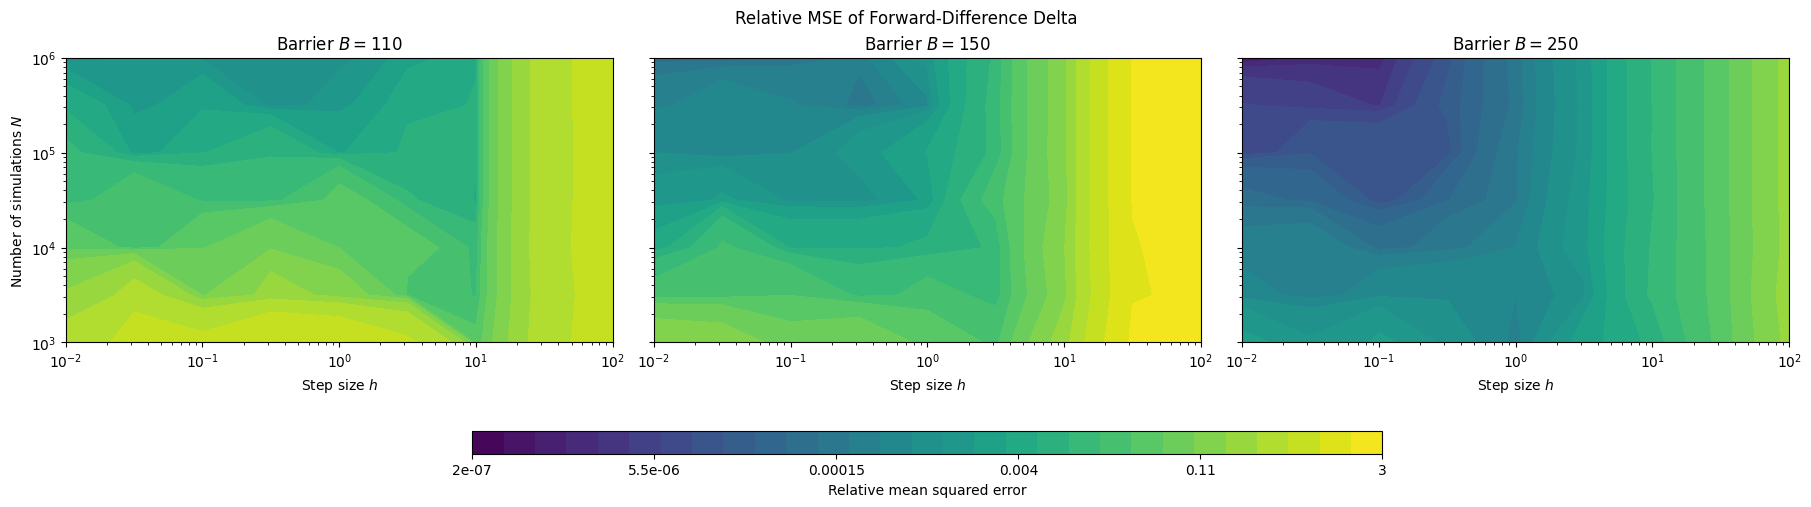

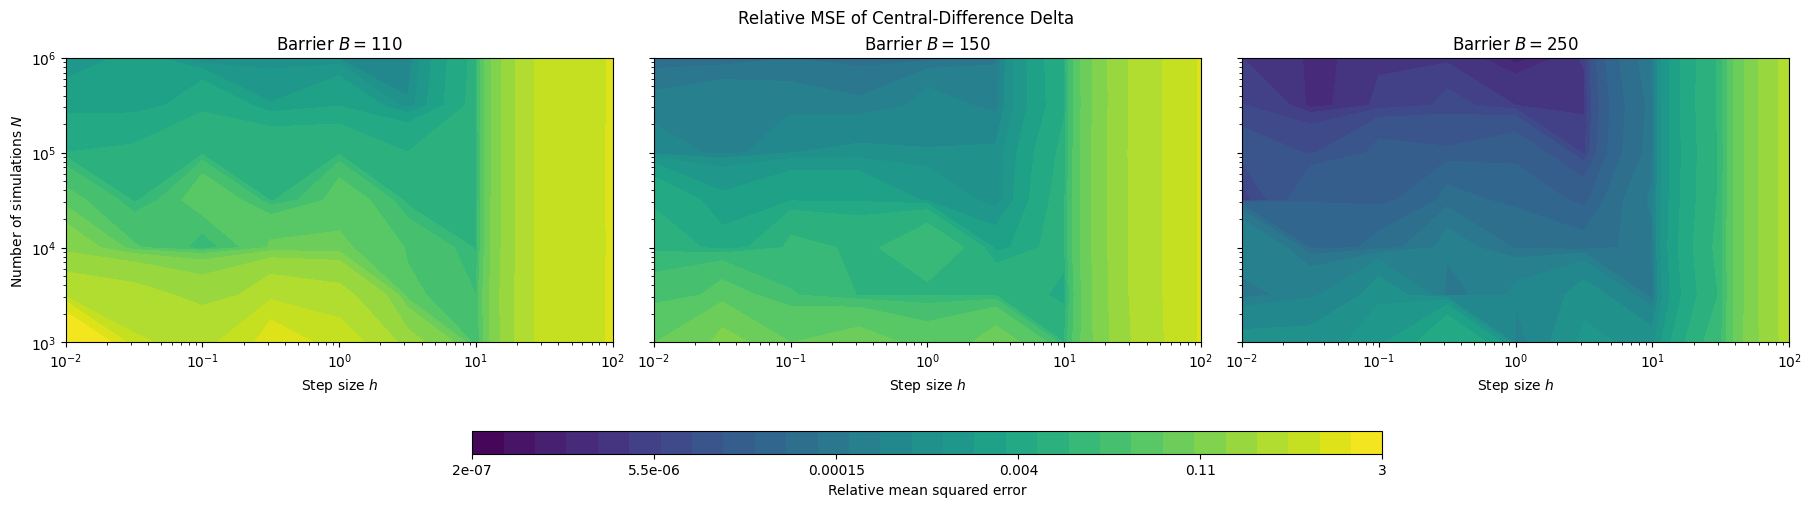

In [10]:
# Grid for the plots
H, N = np.meshgrid(h_values, reps_values)

# Shared colour scale across FD and CD
all_relative_mse = np.concatenate(
    [data.ravel() for data in fd_relative_mse_data] +
    [data.ravel() for data in cd_relative_mse_data]
)

shared_vmin = all_relative_mse[all_relative_mse > 0].min()
shared_vmax = all_relative_mse.max()

levels = np.geomspace(shared_vmin, shared_vmax, 30)
shared_norm = LogNorm(vmin=shared_vmin, vmax=shared_vmax)

titles = [f"Barrier $B={B}$" for B in barrier_values]


# Forward Differences
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

for ax, data, title in zip(axes, fd_relative_mse_data, titles):
    contour = ax.contourf(H,N,data,levels=levels,norm=shared_norm,cmap="viridis")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Step size $h$")
    ax.set_title(title)

axes[0].set_ylabel("Number of simulations $N$")

ticks = np.geomspace(shared_vmin, shared_vmax, 6)
cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=ticks)
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.2g"))
cbar.set_label("Relative mean squared error")

fig.suptitle("Relative MSE of Forward-Difference Delta")

plt.show()


# Central Differences
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

for ax, data, title in zip(axes, cd_relative_mse_data, titles):
    contour = ax.contourf(H,N,data,levels=levels,norm=shared_norm,cmap="viridis")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Step size $h$")
    ax.set_title(title)

axes[0].set_ylabel("Number of simulations $N$")

cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=ticks)
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.2g"))
cbar.set_label("Relative mean squared error")

fig.suptitle("Relative MSE of Central-Difference Delta")

plt.show()

Clearly, the Central Difference method provides better estimations relative to the Forward Difference method. We observe that the MSE is especially large (relative to the true value) on the low-$h$, low-$N$ region. This is explained, as usual, by the fact that variance is amplified by low-$h$ values, despite bias being smaller. The relative error in this region is remarkably large, making approximations useless. 

In general, we observe that at least 10,000 simulations are required for a reliable estimation. However, it is also evident that for larger barriers, the lower limit for the number of simulations $N$ required for a reliable estimation becomes significantly lower. For $B = 250$, for example, even $N = 1,000$ provides a good estimate if $h$ is chosen accordingly. This is because a larger distance to the barrier reduces the effect of the barrier on the option (making it behave closer to a European option), requiring less simulations for accuracy since less 'nuance' must be captured.

Due to the nature of the payoff function, we do not attempt to fit theoretical best-fit surfaces to the above data. However, we observe the approximate optimal $h$ values as a function of the number of reps $N$ and the barrier. For the Forward Difference method, we have

| $N$ | $B=110$ | $B=150$ | $B=250$ |
|---:|---:|---:|---:|
| $1{,}000$ | $1$ | $0.5$ | $0.5$ |
| $10{,}000$ | $1$ | $0.1$ | $0.1$ |
| $100{,}000$ | $1$ | $0.1$ | $0.1$ |
| $1{,}000{,}000$ | $0.1$ | $0.1$ | $0.01$ |

For the Central Difference method, we have

| $N$ | $B=110$ | $B=150$ | $B=250$ |
|---:|---:|---:|---:|
| $1{,}000$ | $10$ | $1$ | $0.5$ |
| $10{,}000$ | $1$ | $0.1$ | $0.1$ |
| $100{,}000$ | $1$ | $1$ | $1$ |
| $1{,}000{,}000$ | $1$ | $0.1$ | $0.01$ |

Note these are approximations that may vary between experiment runs; however, their order of magnitude should be consistently correct.

To conclude this section, we investigate the appropriateness of these methods on a barrier option with a very low barrier, setting $B = 101$. We investigate the relative MSE on the same grid of parameters. 

In [11]:
trials = 5
B = 101

true_delta = theoretical_delta(s,K,B,T,r,vol)
print(f"Barrier = {B}, true Delta = {true_delta:.6f}")

# Rows correspond to reps, columns correspond to h
fd_relative_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_barrier_call_delta_fd_estimate_crn(s,K,B,T,r,vol,steps,reps_i,h_j)
            trial_errors[trial] = ((delta_fd - true_delta) / true_delta)**2
        fd_relative_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
fd_error_table = pd.DataFrame(fd_relative_mse, index=reps_values, columns=h_values)

fd_error_table.index.name = "reps"
fd_error_table.columns.name = "h"

display(fd_error_table)

Barrier = 101, true Delta = -0.000008


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,39.722887,100.541329,4.318718,5.638313,0.529347,0.543280,0.871390,0.948211,0.968225
3162,1.188779,4.313794,8.383497,0.971409,1.117310,0.526024,0.827943,0.950619,0.972391
10000,2.043950,1.787855,1.529616,0.388413,0.209670,0.521102,0.786842,0.936093,0.982019
31622,1.920370,0.341151,0.309562,0.446945,0.025473,0.521246,0.814201,0.942903,0.980415
100000,0.157219,0.277338,0.180808,0.093459,0.023439,0.452915,0.808995,0.935586,0.981221
316227,0.041442,0.030837,0.137208,0.009693,0.006485,0.459903,0.799342,0.934521,0.980230
1000000,0.002634,0.012100,0.009304,0.006697,0.001361,0.470636,0.815019,0.937702,0.981020


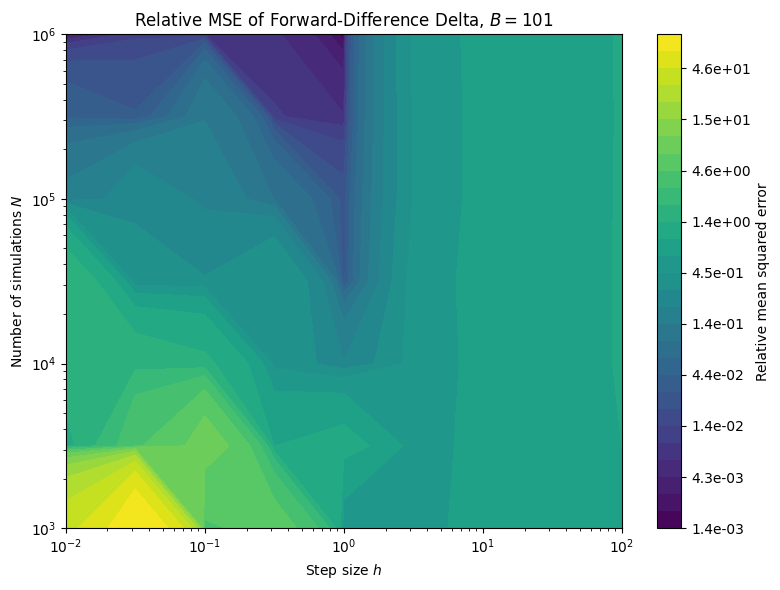

In [12]:
# Grid for the plot
H, REPS = np.meshgrid(h_values, reps_values)

mse_min = fd_relative_mse[fd_relative_mse > 0].min()
mse_max = fd_relative_mse.max()
levels = np.geomspace(mse_min, mse_max, 30)

plt.figure(figsize=(8, 6))

contour = plt.contourf(H,REPS,fd_relative_mse,levels=levels,norm=LogNorm(vmin=mse_min, vmax=mse_max))

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Step size $h$")
plt.ylabel(r"Number of simulations $N$")
plt.title(r"Relative MSE of Forward-Difference Delta, $B=101$")

cbar = plt.colorbar(contour, format="%.1e")
cbar.set_label("Relative mean squared error")

plt.tight_layout()
plt.show()

For the Forward Difference method, we observe half of the grid is dominated by ratios close to or exactly $1$. This is because since both underlying price paths are simulated very close to the barrier, they get almost always knocked out. In particular, for $h \ge 1$, one of the two paths is knocked out from the beginning, making the Delta approximation equal to $0$ whenever the 'lower' path crosses the barrier (which yields an error ratio of $1$). The maximum error ratio attained on the grid is significantly larger this time compared to higher-barrier options, and at least $100,000$ simulations appear to be required for an accurate Delta approximation.



In [13]:
trials = 5
B = 101

true_delta = theoretical_delta(s,K,B,T,r,vol)
print(f"Barrier = {B}, true Delta = {true_delta:.6f}")

# Rows correspond to reps, columns correspond to h
cd_relative_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_barrier_call_delta_cd_estimate_crn(s,K,B,T,r,vol,steps,reps_i,h_j)
            trial_errors[trial] = ((delta_cd - true_delta) / true_delta)**2
        cd_relative_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_error_table = pd.DataFrame(cd_relative_mse, index=reps_values, columns=h_values)

cd_error_table.index.name = "reps"
cd_error_table.columns.name = "h"

display(cd_error_table)

Barrier = 101, true Delta = -0.000008


/Users/oriolmartinezsunyer/Library/Mobile Documents/com~apple~CloudDocs/lobo de las finanzas/mc_delta_estimator/src/payoffs.py:19: RuntimeWarning: divide by zero encountered in divide
  crossing_probs = np.exp(-2 * np.log(B / safe_left_states) * np.log(B / safe_right_states) / (vol**2 * dt))


h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,6.293453,1.567661,6.292864,1.011861,4.731839,0.624535,0.595126,0.755516,1.0
3162,1.547473,1.179762,13.731100,5.045933,0.578314,0.253166,0.281455,0.627384,1.0
10000,1.170400,2.679708,1.609354,0.733227,0.056912,0.237107,0.284038,0.601782,1.0
31622,0.344132,0.303979,0.365256,0.025005,0.062045,0.193000,0.183752,0.633624,1.0
100000,0.195091,0.085097,0.104186,0.188279,0.024528,0.158072,0.230494,0.625650,1.0
316227,0.025476,0.103060,0.059695,0.009604,0.005237,0.109049,0.222117,0.640580,1.0
1000000,0.027363,0.005882,0.030292,0.012995,0.003596,0.110768,0.226967,0.638506,1.0


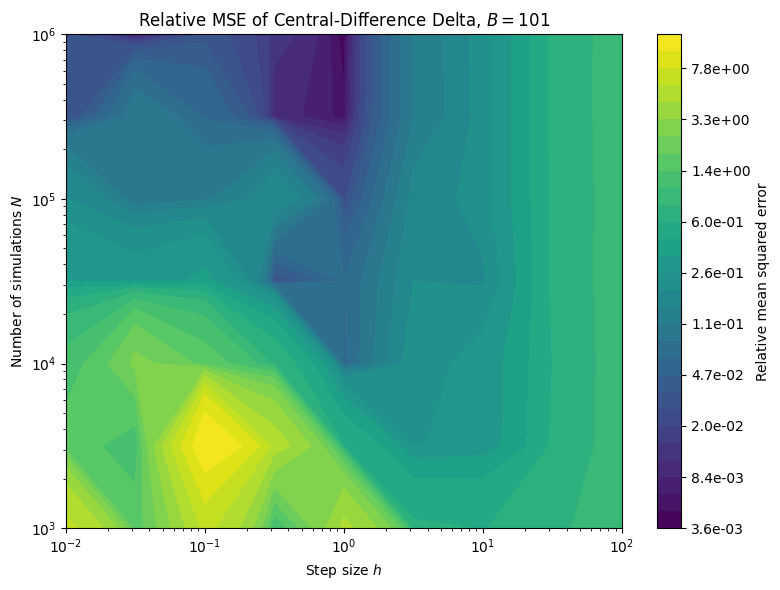

In [14]:
# Grid for the plot
H, REPS = np.meshgrid(h_values, reps_values)

mse_min = cd_relative_mse[cd_relative_mse > 0].min()
mse_max = cd_relative_mse.max()
levels = np.geomspace(mse_min, mse_max, 30)

plt.figure(figsize=(8, 6))

contour = plt.contourf(H,REPS,cd_relative_mse,levels=levels,norm=LogNorm(vmin=mse_min, vmax=mse_max))

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Step size $h$")
plt.ylabel(r"Number of simulations $N$")
plt.title(r"Relative MSE of Central-Difference Delta, $B=101$")

cbar = plt.colorbar(contour, format="%.1e")
cbar.set_label("Relative mean squared error")

plt.tight_layout()
plt.show()

We observe a similar behaviour for the Central Difference method, with the main difference being the fact that ratios of $1$ are not attained as frequently. This is because one of the two simulated paths starts at a lower underlying price value, making a double knockout less likely. Nonetheless, about $100,000$ simulations still seem to be required (under an appropriate value of $h$) for an accurate approximation. Additionally, for $h = 100$ all the ratios equal $1$. This is a malformed though not far-from-accurate result: one path starts already knocked out and the other starts at an initial underlying price of 0, making the multi-step path remain at 0 due to how the underlying stochastic process is defined.

Overall, we observe a clear behaviour: increasing the barrier of an up-and-out barrier call option makes its Delta estimation via Finite Difference methods with CRN more accurate under a fixed number of simulations. This is because high-barrier options resemble European call options, whose Delta is better approximated through these methods. For very low barriers, the MSE of the approximations explodes. Additionally, the Central Difference method provides better approximations overall compared to the Forward Difference method, as seen in all other notebooks, due to lower bias and comparable variance.

## Pathwise Differentiation

The method of Pathwise Differentiation fails in its original form for barrier options, as the barrier option's payoff function is discontinuous due to the indicator function. We therefore replace the binary barrier event by its Brownian-bridge conditional survival probability. For each interval, the Brownian bridge gives the probability $p_i$ of crossing the barrier between two simulated states, so the conditional probability that the full path survives is

$$
\prod_i (1-p_i).
$$

The conditional payoff can therefore be written as

$$
e^{-rT}(S_T-K)^+\prod_i (1-p_i),
$$

which is differentiable with respect to the initial spot along surviving paths. Differentiating this expression pathwise gives two contributions to Delta: the usual sensitivity of the terminal payoff, and the sensitivity of the barrier-survival probability. The estimator is given by 

$$
\widehat{\Delta}_{PW}
=
\frac{1}{N}
\sum_{j=1}^N
e^{-rT}
\left[
\mathbf{1}_{\{S_T^{(j)}>K\}}
\frac{S_T^{(j)}}{S_0}
P_{\mathrm{surv}}^{(j)}
+
(S_T^{(j)}-K)^+
\frac{\partial P_{\mathrm{surv}}^{(j)}}{\partial S_0}
\right],
$$

where $P_{\mathrm{surv}}^{(j)}$ is the Brownian-bridge conditional probability that path $j$ remains below the barrier over the full interval,

$$
P_{\mathrm{surv}}^{(j)}=\prod_i (1-p_i^{(j)}),
$$

and $\partial P_{\mathrm{surv}}^{(j)}/\partial S_0$ is the sensitivity of this survival probability to the initial stock price.


We begin by investigating the MSE of the estimator on a moneyness-volatility grid (as done for the pathwise estimator of all other options) for different barriers. In this case, moneyness and barrier proximity interact: changing the strike changes not only the terminal payoff but also the importance of the barrier relative to the region in which the option finishes in the money. We therefore consider several barrier levels and interpret the resulting MSE surfaces jointly in terms of moneyness, volatility, and barrier proximity.

In [15]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [16]:
barrier_values = [101,110,150,250]
trials = 10

pw_relative_mse_results = {}

for B in barrier_values:
    pw_relative_mse = np.empty((len(moneyness_values),len(vol_values)))
    for i,moneyness_i in enumerate(moneyness_values):
        s_i = K*moneyness_i
        for j,vol_j in enumerate(vol_values):
            true_delta = theoretical_delta(s_i,K,B,T,r,vol_j)
            trial_errors = np.empty(trials)
            for trial in range(trials):
                delta_pw = pathwise.mc_barrier_call_delta_pw_estimate(s_i,K,B,T,r,vol_j,steps,reps)
                trial_errors[trial] = ((delta_pw-true_delta)/true_delta)**2
                
            pw_relative_mse[i,j] = np.mean(trial_errors)

    pw_relative_mse_results[B] = pw_relative_mse

    pw_error_table = pd.DataFrame(pw_relative_mse,index=moneyness_values,columns=vol_values)
    pw_error_table.index.name = "moneyness"
    pw_error_table.columns.name = "vol"

    print(f"Barrier = {B}")
    display(pw_error_table)

/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/1715007442.py:15: RuntimeWarning: invalid value encountered in scalar divide
  trial_errors[trial] = ((delta_pw-true_delta)/true_delta)**2


Barrier = 101


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1897.159398,3.939695e+02,1193.402881,369.850225,6.853766e+02,1549.652135,4798.937668,7144.161188,8750.413298,3.589047e+04,...,471019.475282,157704.247594,378151.308642,117172.333294,60829.762557,122917.317378,122391.617752,115259.134430,29934.242975,81806.853141
0.725,147.426669,4.187113e+02,522.773862,453.116482,1.288620e+03,4835.208158,11407.652320,12528.237437,27749.797542,9.655062e+04,...,16036.573815,118268.404519,149279.171685,98549.784288,174014.342390,39962.685939,77355.629386,50804.846072,735.334549,93023.198330
0.750,1195.388561,2.680500e+02,466.353693,604.532917,4.292602e+02,3732.977808,6573.243396,16754.426855,157866.509851,1.277229e+07,...,4249.160423,29200.935511,10736.059797,23692.053294,95462.691057,44410.450792,22312.392362,76575.319183,56766.984820,29137.463946
0.775,193.053736,2.018440e+02,275.697690,813.266710,4.728563e+03,1652.588344,27156.517234,242131.503537,647764.754819,6.327437e+04,...,20198.862213,3028.851657,9828.971917,9968.333784,21014.607090,18932.631776,51234.012939,119988.136976,26142.729094,7896.394963
0.800,119.545996,8.579405e+01,1171.380157,5357.644319,9.782409e+03,102237.235099,719575.362841,24513.295254,22220.603428,1.669483e+04,...,10075.278703,4857.310325,4093.627252,6450.776714,13735.678148,4434.880069,1529.109698,8361.278282,12131.934596,19813.561835
0.825,218.852865,8.096157e+02,551.404597,7478.663137,2.679716e+06,15937.308813,12869.821607,8440.616084,8412.325706,8.532037e+03,...,9851.193723,11597.348473,8819.559298,6743.306526,14813.035006,12180.288222,10166.858947,19686.748812,2157.442120,12129.054230
0.850,195.502610,1.943164e+03,15717.768853,65324.584103,1.875632e+04,6865.813451,6725.948688,4893.010154,10997.275737,4.994487e+03,...,3080.489007,4205.418163,16468.927992,4661.893041,1691.642722,2903.947758,1334.085227,613.736103,2639.271028,12492.337760
0.875,856.573185,1.820473e+06,7287.343960,2541.056799,1.908865e+03,1602.761970,2785.128345,1438.052728,4924.703224,3.311384e+03,...,2979.981610,7933.840835,2596.461297,14896.697700,3523.460851,7710.304634,7190.957894,7945.223594,5047.469395,9289.339449
0.900,5617.263162,8.596325e+02,1262.228974,1088.802817,6.703885e+02,1126.516020,369.756782,772.878936,630.887859,3.047306e+03,...,1274.236437,2417.472969,362.383073,7845.914893,1003.948446,16.573546,4702.978460,9938.944706,10749.702546,5541.605106


/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/1715007442.py:15: RuntimeWarning: invalid value encountered in scalar divide
  trial_errors[trial] = ((delta_pw-true_delta)/true_delta)**2


Barrier = 110


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,2.928594,1.385781,0.889259,1.755329,0.513832,2.964533,2.433255,2.593680e+00,4.088963,3.403411,...,94.545741,385.218696,1130.791504,12130.319183,11910.833036,4106.774433,1517.588523,421.204414,308.686693,517.000011
0.725,0.974591,0.397523,0.291035,0.853119,0.337508,1.889240,0.962079,2.151674e+00,11.622186,10.978002,...,1059.985346,59357.731025,6259.031598,642.945360,523.627648,343.515948,275.811138,215.434173,222.672171,73.768128
0.750,0.575027,0.352886,0.305903,0.650937,1.098315,1.970169,1.282809,5.272319e+00,5.839890,11.804490,...,3319.266370,628.593995,480.205685,280.632123,82.836679,137.292794,240.754076,34.759028,92.491616,66.610177
0.775,0.223533,0.237225,0.170341,0.510165,1.130668,1.494910,2.332755,5.044186e+00,12.055656,26.896021,...,189.714002,114.214274,48.039164,111.966070,33.110018,79.776194,9.863625,55.221345,34.710589,51.935413
0.800,0.175869,0.194626,0.189093,0.738214,0.937231,5.072448,4.149703,1.884894e+01,35.652189,80.211106,...,22.883056,40.366294,29.372365,28.167146,70.604294,60.446628,57.977530,12.482502,34.640333,91.916761
0.825,0.201104,0.185296,0.343749,0.844328,1.030206,2.953042,21.003288,4.101407e+01,449.848251,3779.730134,...,33.456156,32.314173,33.481766,40.580461,46.694440,17.009660,17.220562,37.319624,17.834990,83.779209
0.850,0.038507,0.242770,0.384222,0.944898,3.401222,12.968037,41.247456,8.252842e+06,134.555901,33.518689,...,9.019956,12.793667,24.606226,31.326599,13.190190,23.887935,20.632870,15.262698,35.031328,23.223204
0.875,0.103717,0.183278,0.251138,1.927886,23.210383,451.766723,68.691373,2.526811e+01,20.734873,21.639211,...,14.363019,10.314926,9.272419,9.242150,14.125611,9.452276,14.841628,26.353475,9.841769,16.818246
0.900,0.246949,0.772272,3.036874,21.980744,1204.424192,29.305625,14.354692,3.619367e+00,6.153758,3.322653,...,10.725943,8.346736,12.704955,18.241160,10.393701,9.950351,12.044242,4.685464,11.012552,7.276644


Barrier = 150


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.673760,0.135487,0.071000,0.085115,0.038409,0.015460,0.032656,0.010891,0.024638,0.076013,...,0.158453,0.091506,0.223227,0.448713,0.284514,0.375769,0.897510,1.468865,0.886318,0.790023
0.725,0.171297,0.183946,0.057043,0.013711,0.013261,0.027082,0.021395,0.019113,0.026122,0.033206,...,0.074235,0.148531,0.395675,0.478981,0.314467,0.336680,0.260372,0.894799,0.834353,2.069504
0.750,0.262686,0.031974,0.019574,0.026483,0.006357,0.016665,0.016746,0.007418,0.040025,0.045254,...,0.162581,0.246497,0.085763,0.668421,0.424230,0.410560,1.001312,0.820790,2.372116,1.328526
0.775,0.050221,0.008235,0.015496,0.008940,0.019136,0.008297,0.016226,0.019999,0.007431,0.030421,...,0.151960,0.289981,0.265782,0.275378,0.460109,1.223077,0.732138,2.213202,1.883105,4.167783
0.800,0.009955,0.005990,0.015864,0.004703,0.007158,0.010164,0.021765,0.017292,0.039299,0.054277,...,0.421673,0.200640,0.449580,0.234660,0.490596,1.142544,0.900535,2.604655,2.100021,6.843174
0.825,0.010362,0.006614,0.003427,0.006073,0.014014,0.005656,0.008343,0.014231,0.034072,0.024387,...,0.331889,0.361427,0.490537,0.411921,0.763286,1.845333,1.020990,7.094928,8.602776,8.977130
0.850,0.005242,0.002053,0.002429,0.002317,0.009644,0.011718,0.013266,0.029969,0.040424,0.042494,...,0.351564,0.933282,0.748242,2.492108,1.054641,3.124036,2.889563,14.857416,35.566711,52.301022
0.875,0.003004,0.001735,0.005029,0.004724,0.005275,0.007723,0.020641,0.008226,0.048368,0.090909,...,0.686645,1.325701,0.931822,3.102794,5.234788,12.444550,36.014469,54.003274,925.520164,470.855189
0.900,0.001855,0.002780,0.001816,0.008298,0.008389,0.010189,0.015830,0.027618,0.042739,0.094316,...,0.836549,0.568618,2.992232,2.022178,10.913858,54.020200,1384.710432,348.793689,26.282694,13.813329


Barrier = 250


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.690459,0.159912,0.040989,0.023690,0.038378,0.010321,0.015067,0.011525,0.003245,0.011144,...,0.020757,0.005268,0.007118,0.017154,0.003749,0.007122,0.060143,0.025409,0.037566,0.030930
0.725,0.309077,0.170615,0.051998,0.013555,0.006604,0.025855,0.005458,0.008010,0.004453,0.006399,...,0.027037,0.020930,0.011414,0.024294,0.008558,0.013303,0.015224,0.017627,0.011190,0.037580
0.750,0.074587,0.022046,0.030371,0.031129,0.016106,0.010979,0.004616,0.007419,0.006220,0.008588,...,0.006673,0.008072,0.007798,0.012365,0.003553,0.033557,0.027186,0.021615,0.069073,0.011974
0.775,0.036083,0.027341,0.016482,0.011234,0.008062,0.005480,0.004408,0.003528,0.004693,0.006246,...,0.015127,0.007861,0.015115,0.022505,0.010038,0.013210,0.029579,0.045769,0.043710,0.020466
0.800,0.019359,0.017291,0.003228,0.006414,0.007964,0.003563,0.005143,0.001714,0.007339,0.004271,...,0.006242,0.032704,0.015757,0.012474,0.010160,0.034341,0.025463,0.012731,0.038733,0.037274
0.825,0.007459,0.006853,0.006262,0.004293,0.003600,0.006151,0.002209,0.002051,0.001405,0.007639,...,0.014352,0.010328,0.010157,0.024674,0.007931,0.041332,0.014792,0.041022,0.031251,0.011419
0.850,0.003341,0.007446,0.005362,0.006380,0.003484,0.003763,0.004374,0.004192,0.003047,0.004037,...,0.007272,0.006457,0.008151,0.007178,0.023004,0.038570,0.030701,0.027021,0.029007,0.041639
0.875,0.002525,0.004881,0.003969,0.001333,0.002497,0.001917,0.004811,0.001554,0.002429,0.001207,...,0.003943,0.013004,0.017963,0.029599,0.008586,0.075730,0.022442,0.019978,0.057282,0.017349
0.900,0.005098,0.003798,0.002958,0.001312,0.001964,0.002132,0.001830,0.003840,0.002902,0.004517,...,0.002845,0.016117,0.005938,0.009782,0.005017,0.016795,0.032432,0.017087,0.028295,0.062702


As expected, for low barriers, a high enough moneyness knocks the option out from the very start, as we have $S_0 \ge B$. These corresponds to the 'NaN' relative MSE values in the table above.

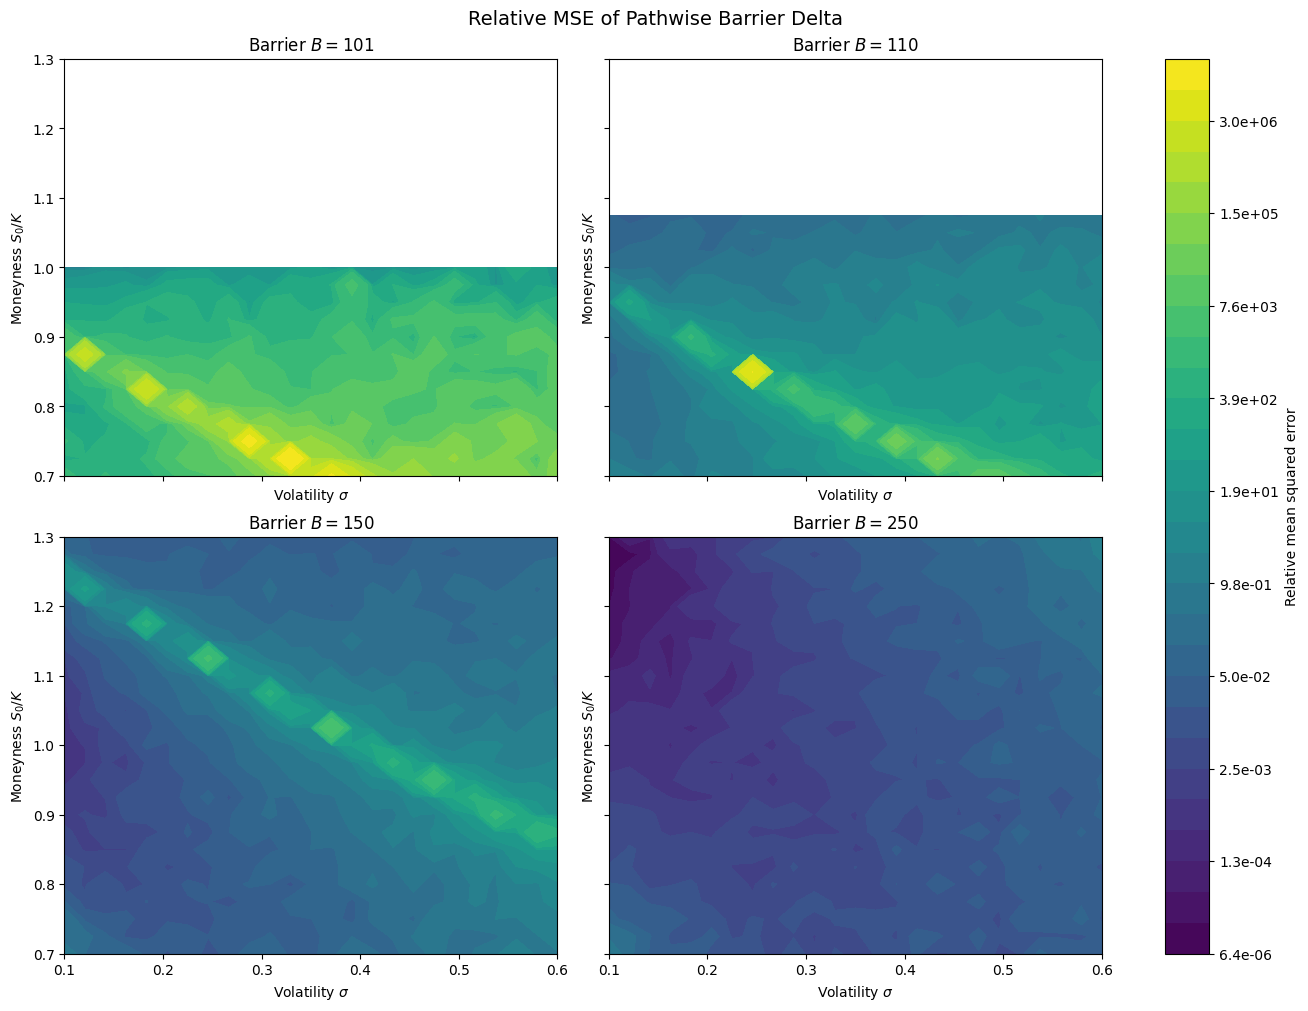

In [17]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

all_mse = np.concatenate([mse.ravel() for mse in pw_relative_mse_results.values()])
positive_finite_mse = all_mse[np.isfinite(all_mse) & (all_mse > 0)]

mse_min = positive_finite_mse.min()
mse_max = positive_finite_mse.max()

levels = np.geomspace(mse_min, mse_max, 30)
normalisation = LogNorm(vmin=mse_min, vmax=mse_max)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True, constrained_layout=True)

for ax, (B, pw_relative_mse) in zip(axes.ravel(), pw_relative_mse_results.items()):
    plot_data = np.ma.masked_invalid(pw_relative_mse)
    contour = ax.contourf(VOL, MONEYNESS, plot_data, levels=levels, norm=normalisation)
    ax.set_xlabel(r"Volatility $\sigma$")
    ax.set_ylabel(r"Moneyness $S_0/K$")
    ax.set_title(rf"Barrier $B={B}$")

cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), format="%.1e")
cbar.set_label("Relative mean squared error")

fig.suptitle("Relative MSE of Pathwise Barrier Delta", fontsize=14)

plt.show()

Note that the 'white' regions correspond to 'NaN' values. 

The results show two main effects. First, the bright diagonal ridges are not regions where the estimator becomes intrinsically poor. They occur where the true barrier-option Delta is close to zero, so relative MSE becomes very large because even a modest estimation error is divided by a very small true value. The location of this zero-Delta region changes with volatility and barrier level, producing the diagonal pattern (the plot corresponding to $B = 250$ does not include high enough moneyness values for the ridge to be visible).

Away from these ridges, the broader pattern is more informative about estimator performance. Pathwise differentiation performs better when volatility is low and when the barrier is far from the initial spot. In those cases, barrier crossings are relatively unlikely, so the estimator behaves more like the standard smooth pathwise estimator for a European call. As volatility increases, or as the barrier moves closer to the spot, barrier-crossing risk becomes more important and the survival-probability component of the estimator becomes more variable, increasing the relative MSE. 

## Likelihood-Ratio

We now implement the Likelihood-Ratio method adapted to barrier options. Using the Brownian-bridge representation of the continuously monitored barrier payoff, the Likelihood-Ratio estimator contains two contributions. The first is the usual LR score associated with the first transition of the simulated path, while the second accounts for the explicit dependence of the first Brownian-bridge survival probability on the initial spot. The estimator is

$$
\widehat{\Delta}_{LR}
=
\frac{1}{N}
\sum_{j=1}^{N}
e^{-rT}(S_T^{(j)}-K)^+
\left[
P_{\mathrm{surv}}^{(j)}
\frac{Z_1^{(j)}}{S_0\sigma\sqrt{\Delta t}}
+
\frac{\partial P_{\mathrm{surv}}^{(j)}}{\partial S_0}
\right],
$$

where

$$
P_{\mathrm{surv}}^{(j)}
=
\prod_i(1-p_i^{(j)}).
$$

Only the first transition contributes to the LR score, and only the first Brownian-bridge interval depends explicitly on $S_0$ when the remaining simulated states are held fixed.

//ADD REFERENCES IN 01_estimator_theory.ipynb//

We begin by investigating the MSE on the usual moneyness-volatility grid for different barrier values.

In [18]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [19]:
barrier_values = [101,110,150,250]
trials = 10

lr_relative_mse_results = {}

for B in barrier_values:
    lr_relative_mse = np.empty((len(moneyness_values),len(vol_values)))
    for i,moneyness_i in enumerate(moneyness_values):
        s_i = K*moneyness_i
        for j,vol_j in enumerate(vol_values):
            true_delta = theoretical_delta(s_i,K,B,T,r,vol_j)
            trial_errors = np.empty(trials)
            for trial in range(trials):
                delta_lr = likelihood_ratio.mc_barrier_call_delta_lr_estimate(s_i,K,B,T,r,vol_j,steps,reps)
                trial_errors[trial] = ((delta_lr-true_delta)/true_delta)**2

            lr_relative_mse[i,j] = np.mean(trial_errors)

    lr_relative_mse_results[B] = lr_relative_mse
    lr_error_table = pd.DataFrame(lr_relative_mse,index=moneyness_values,columns=vol_values)
    lr_error_table.index.name = "moneyness"
    lr_error_table.columns.name = "vol"

    print(f"Barrier = {B}")
    display(lr_error_table)

/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/2483907118.py:15: RuntimeWarning: invalid value encountered in scalar divide
  trial_errors[trial] = ((delta_lr-true_delta)/true_delta)**2


Barrier = 101


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,10.950241,1.529677,0.534758,0.903065,2.156877,5.554810,5.892700,9.659833,1.047250,52.833377,...,162.892327,102.067689,99.319668,21.904836,142.306367,9.492644,27.490482,12.663166,23.070030,25.092538
0.725,2.745830,10.840549,1.420375,0.803959,1.777268,11.358520,2.957994,15.546794,36.360305,114.752227,...,65.065636,262.815960,16.741479,15.869201,42.989545,7.953579,14.513933,1.073727,7.359679,11.847491
0.750,3.210996,6.073969,0.485924,3.846266,2.306477,6.671881,29.256186,108.658675,120.820357,4412.186180,...,3.981846,17.830571,3.154503,16.465546,15.572956,4.622350,2.605394,2.514164,5.314446,7.624175
0.775,0.991466,1.815236,2.702438,10.638900,11.898054,11.372274,22.500144,106.140742,516.211100,305.547552,...,16.136518,3.300273,5.059976,9.627304,0.869512,2.577214,1.044512,1.023897,1.673821,3.935449
0.800,8.848190,2.273533,6.594214,5.604900,62.993208,105.830642,1354.409937,95.734356,108.117247,7.202428,...,2.039175,2.360907,9.977459,1.811702,2.540011,3.242879,3.803670,7.498299,5.262211,1.550548
0.825,1.697866,3.465517,2.964464,100.684466,8905.275766,366.803367,20.781478,8.920111,21.052127,4.724706,...,6.741552,1.497539,1.534095,1.052003,1.124310,0.929239,5.497884,2.810714,6.788642,0.975996
0.850,4.253738,14.903058,75.024619,349.525835,70.890134,3.066340,18.907313,2.888445,2.025261,4.600905,...,29.768529,3.853333,13.153968,0.802768,2.449508,0.725273,0.812051,2.690612,0.718617,1.432819
0.875,24.411757,35175.166334,29.506221,6.998269,6.263741,7.157724,6.387014,1.787637,1.140721,1.817561,...,7.115209,0.568574,3.186119,7.309979,0.655868,4.516992,0.985090,0.675753,0.945925,1.268074
0.900,48.967378,4.207538,2.084330,2.045605,0.958289,2.566510,1.482696,1.161473,3.375174,2.399073,...,1.599417,1.219884,0.746948,7.594940,1.042632,0.900412,1.358039,9.054511,2.176219,1.030783


/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/2483907118.py:15: RuntimeWarning: invalid value encountered in scalar divide
  trial_errors[trial] = ((delta_lr-true_delta)/true_delta)**2


Barrier = 110


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.844122,2.955231,0.341700,0.252295,0.046367,0.127323,0.152726,0.234407,0.549904,0.263826,...,3.185284,19.357749,27.585885,567.989366,200.771588,79.211487,13.345016,20.307981,17.623858,6.568443
0.725,1.169865,0.377112,0.256066,0.156994,0.255243,0.438149,0.346711,0.484927,0.234306,1.021555,...,41.797404,779.976352,176.900452,16.696994,22.145526,34.742814,6.306942,2.317512,5.283248,3.329907
0.750,0.453520,0.088298,0.148446,0.193581,0.112954,0.137117,0.350173,0.279831,1.104748,1.103235,...,84.909284,14.147721,4.102262,3.892328,3.790416,1.811208,2.535251,0.693530,1.560322,0.271452
0.775,0.250891,0.046986,0.096692,0.314573,0.196607,0.210262,0.255213,0.328299,1.184995,1.032433,...,6.658477,7.586261,5.426450,0.645209,2.345617,2.141274,1.047204,1.004456,1.573861,1.558143
0.800,0.079200,0.092262,0.131250,0.081120,0.205413,0.196400,1.141717,1.480299,1.448522,9.029319,...,2.313156,1.096197,1.210850,0.676803,0.820160,0.783416,0.413343,0.974978,0.863167,0.757675
0.825,0.066553,0.021570,0.096176,0.114364,0.226082,0.996730,1.108582,5.321045,14.226486,89.649468,...,1.297310,1.266873,1.097487,0.714053,0.759386,2.434627,0.674523,0.359850,1.032135,0.876263
0.850,0.050360,0.079624,0.173628,0.140703,0.677947,1.168412,9.306809,656355.826541,21.305067,3.396313,...,1.061843,0.431503,0.564556,0.430129,0.417567,0.506425,0.819896,0.062768,0.560169,0.448196
0.875,0.121412,0.212652,0.378006,0.337406,2.575545,41.401227,21.121763,4.952094,3.341741,0.774686,...,0.204440,0.617624,0.398598,0.364464,0.109559,0.508478,0.299849,0.241553,0.386402,0.279031
0.900,0.067751,0.128146,0.498945,2.657520,217.603536,2.682861,0.501703,0.845325,0.504205,0.106863,...,0.209015,0.558315,0.264097,0.210279,0.333523,0.158737,0.230167,0.406051,0.205133,0.171644


Barrier = 150


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.637581,0.828119,0.256068,0.176518,0.120005,0.016373,0.060209,0.114207,0.012346,0.035391,...,0.138058,0.098051,0.040074,0.135693,0.213192,0.199515,0.079787,0.280849,0.291082,0.330944
0.725,0.531644,0.766726,0.477638,0.105963,0.067377,0.113035,0.025986,0.036578,0.177698,0.044025,...,0.097295,0.084802,0.086555,0.089328,0.070698,0.039423,0.412267,0.216272,0.410008,0.379039
0.750,0.383095,0.212184,0.117275,0.079361,0.077523,0.079572,0.049039,0.090231,0.034768,0.012741,...,0.072811,0.049491,0.064086,0.084446,0.114482,0.139225,0.129014,0.233683,0.919967,0.161118
0.775,0.234196,0.134700,0.073682,0.136180,0.039387,0.006091,0.056610,0.077211,0.044392,0.014952,...,0.111526,0.117670,0.213958,0.130712,0.054798,0.437834,0.103412,0.984257,0.479904,0.494011
0.800,0.067664,0.087457,0.066017,0.044196,0.032870,0.056403,0.045274,0.090128,0.053726,0.019546,...,0.111116,0.054868,0.085317,0.236870,0.341046,0.232924,0.427207,0.389636,1.075974,1.010155
0.825,0.074471,0.058083,0.064410,0.029259,0.023978,0.018667,0.026819,0.036074,0.027033,0.086094,...,0.290138,0.150810,0.171487,0.224244,0.520663,0.624385,1.101027,0.722130,3.263708,2.964387
0.850,0.056865,0.019347,0.040571,0.036904,0.042459,0.058665,0.024053,0.037407,0.019475,0.020223,...,0.263511,0.133604,0.376763,0.200116,0.407759,1.873437,2.382203,4.141813,6.024861,31.903813
0.875,0.035210,0.050260,0.014425,0.054633,0.021918,0.030997,0.033655,0.054032,0.062669,0.087433,...,0.370535,0.210260,0.357623,1.032888,1.080181,3.325515,4.893272,10.868501,492.053509,79.586954
0.900,0.014485,0.045666,0.028243,0.018626,0.034272,0.025481,0.018822,0.038512,0.074376,0.112653,...,0.731216,0.568779,0.399363,0.887995,6.400603,15.774361,96.334545,69.417466,9.213787,4.879034


Barrier = 250


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.408391,0.384042,0.160756,0.133117,0.042037,0.050609,0.026384,0.042234,0.048409,0.063238,...,0.022614,0.022852,0.043995,0.032563,0.052764,0.026189,0.037983,0.053200,0.041588,0.029910
0.725,1.459454,0.218956,0.284052,0.215186,0.071874,0.079745,0.091845,0.070283,0.005112,0.064228,...,0.058861,0.040383,0.056876,0.079318,0.027789,0.045005,0.064423,0.055116,0.057793,0.032279
0.750,0.217012,0.227982,0.115053,0.076407,0.051936,0.036571,0.114826,0.068143,0.042968,0.042394,...,0.035433,0.051636,0.021892,0.040198,0.031794,0.040310,0.029148,0.042128,0.092624,0.021319
0.775,0.160052,0.114041,0.055229,0.040487,0.052992,0.038426,0.030882,0.051938,0.037994,0.045941,...,0.015160,0.016272,0.056882,0.012411,0.061141,0.066708,0.016445,0.028605,0.021066,0.016288
0.800,0.124220,0.037721,0.051771,0.020702,0.037652,0.039424,0.053511,0.025600,0.036808,0.034750,...,0.018141,0.013459,0.025010,0.059128,0.025897,0.031621,0.038602,0.032691,0.061130,0.054293
0.825,0.093965,0.045528,0.035485,0.032370,0.027364,0.032902,0.037967,0.064330,0.025594,0.019881,...,0.027470,0.029242,0.053157,0.030662,0.031339,0.040084,0.029419,0.028917,0.041933,0.046447
0.850,0.035988,0.041127,0.027703,0.033140,0.035922,0.033984,0.040565,0.021160,0.044717,0.025504,...,0.035975,0.032241,0.084731,0.056916,0.043313,0.051563,0.034607,0.031518,0.041747,0.038031
0.875,0.081898,0.028488,0.019070,0.020466,0.043754,0.036900,0.058431,0.023681,0.015106,0.019942,...,0.022154,0.020038,0.019344,0.019733,0.036467,0.044554,0.067193,0.039580,0.029480,0.052474
0.900,0.045922,0.012859,0.039689,0.029431,0.027813,0.059058,0.020019,0.016483,0.024314,0.012218,...,0.025178,0.016698,0.026724,0.055048,0.101650,0.029521,0.059012,0.031900,0.083334,0.095959


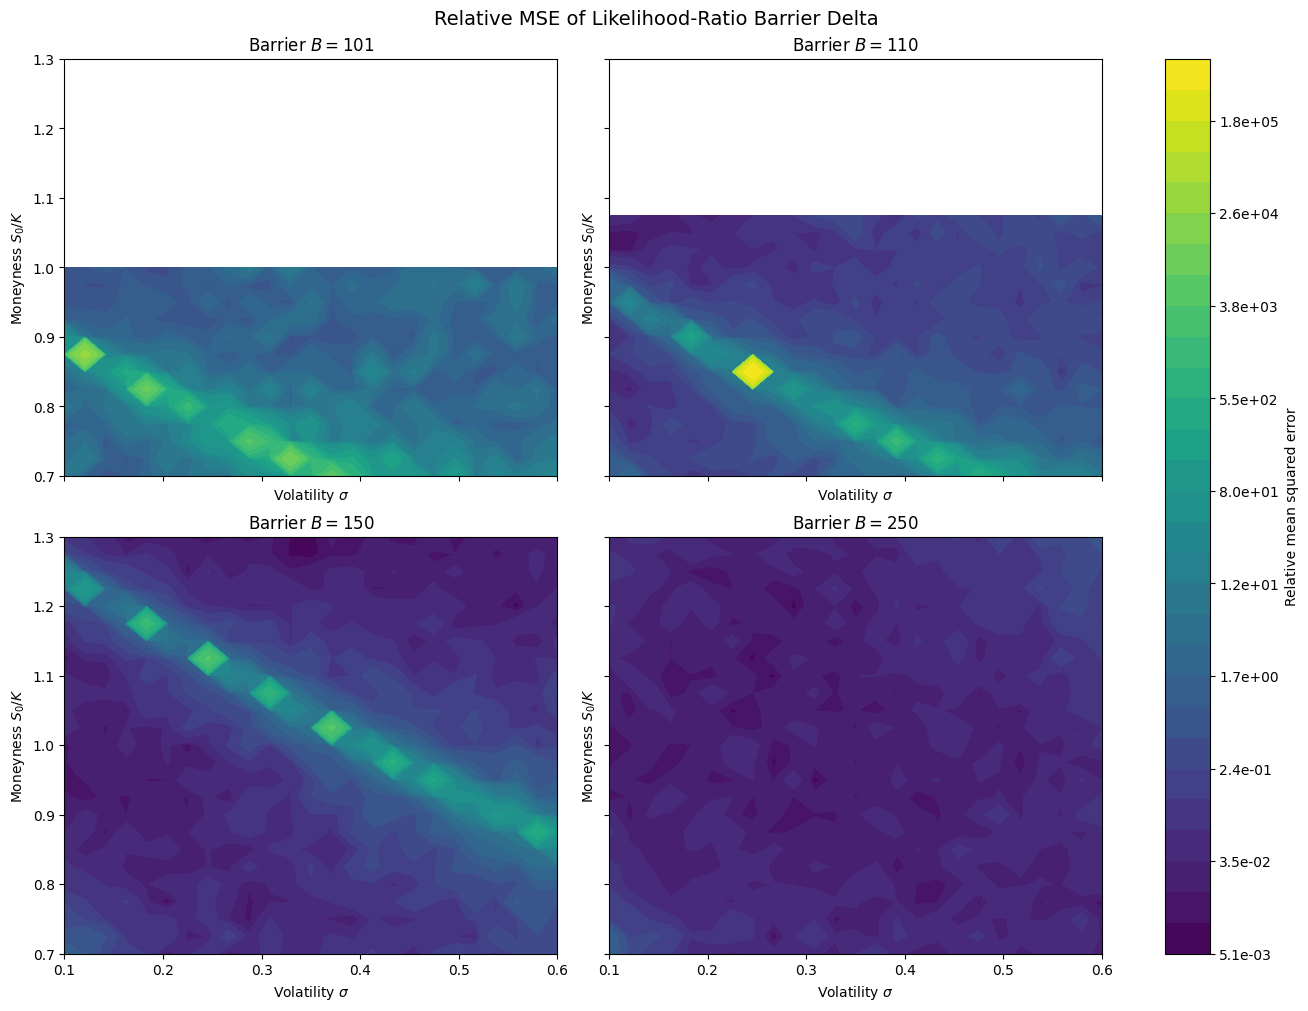

In [20]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

all_mse = np.concatenate([mse.ravel() for mse in lr_relative_mse_results.values()])
positive_finite_mse = all_mse[np.isfinite(all_mse) & (all_mse > 0)]

mse_min = positive_finite_mse.min()
mse_max = positive_finite_mse.max()

levels = np.geomspace(mse_min, mse_max, 30)
normalisation = LogNorm(vmin=mse_min, vmax=mse_max)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True, constrained_layout=True)

for ax, (B, lr_relative_mse) in zip(axes.ravel(), lr_relative_mse_results.items()):
    plot_data = np.ma.masked_invalid(lr_relative_mse)

    contour = ax.contourf(VOL, MONEYNESS, plot_data, levels=levels, norm=normalisation)

    ax.set_xlabel(r"Volatility $\sigma$")
    ax.set_ylabel(r"Moneyness $S_0/K$")
    ax.set_title(rf"Barrier $B={B}$")

cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), format="%.1e")
cbar.set_label("Relative mean squared error")

fig.suptitle("Relative MSE of Likelihood-Ratio Barrier Delta", fontsize=14)

plt.show()

We observe a very similar pattern to that for Pathwise Differentation: a diagonal ridge of high MSE ratio values which shifts upward for larger barrier values, lower MSE ratios for larger barrier values, and an expected 'NaN' region for the two lowest barriers after a given moneyness value.

The ridge is, once again, explained by the fact that the Delta on it is very small, magnifying the error ratio despite a possibly small absolute error of the approximation. The Likelihood-Ratio method appears to provide more consistent low errors across the different plots, and is not affected as much by varying volatility. The errors are comparable in magnitude to the Pathwise Differentation method, in general.

Next, we implement Payoff Centring as usual and investigate their effectiveness in reducing the MSE on the same grid.

In [21]:
def mc_barrier_call_lr_optimal_c(s,K,B,T,r,vol,steps,reps):
    dt = T/steps
    Z = np.random.standard_normal((reps,steps))
    paths = path_simulator.multiple_step_paths(s,T,r,vol,steps,reps,Z)
    scores = Z[:,0]/(s*vol*np.sqrt(dt))

    conditional_payoffs = np.zeros(reps)
    survival_gradient_terms = np.zeros(reps)
    valid_paths = np.all(paths < B,axis=1)
    valid_states = paths[valid_paths]
    left_states = valid_states[:,:-1]
    right_states = valid_states[:,1:]

    crossing_probs = np.exp(-2*np.log(B/left_states)*np.log(B/right_states)/(vol**2*dt))
    survival_probs = np.prod(1-crossing_probs,axis=1)
    p0 = crossing_probs[:,0]
    dp0 = p0*2*np.log(B/right_states[:,0])/(s*vol**2*dt)
    remaining_survival = np.prod(1-crossing_probs[:,1:],axis=1)
    survival_gradients = -dp0*remaining_survival

    payoff = np.maximum(valid_states[:,-1]-K,0)
    conditional_payoffs[valid_paths] = payoff*survival_probs
    survival_gradient_terms[valid_paths] = payoff*survival_gradients
    uncentred_terms = conditional_payoffs*scores + survival_gradient_terms
    c = np.sum(uncentred_terms*scores)/np.sum(scores**2)
    return c

In [22]:
barrier_values = [101,110,150,250]
trials = 10
pilot_reps = 1_000

lr_centred_relative_mse_results = {}

for B in barrier_values:
    lr_centred_relative_mse = np.empty((len(moneyness_values),len(vol_values)))
    for i,moneyness_i in enumerate(moneyness_values):
        s_i = K*moneyness_i
        for j,vol_j in enumerate(vol_values):
            true_delta = theoretical_delta(s_i,K,B,T,r,vol_j)
            # Estimate optimal centring constant using a separate pilot sample
            c = mc_barrier_call_lr_optimal_c(s_i,K,B,T,r,vol_j,steps,pilot_reps)
            trial_errors = np.empty(trials)
            for trial in range(trials):
                delta_lr_centred = likelihood_ratio.mc_barrier_call_delta_lr_centred_estimate(s_i,K,B,T,r,vol_j,steps,reps,c)
                trial_errors[trial] = ((delta_lr_centred-true_delta)/true_delta)**2

            lr_centred_relative_mse[i,j] = np.mean(trial_errors)

    lr_centred_relative_mse_results[B] = lr_centred_relative_mse
    lr_centred_error_table = pd.DataFrame(lr_centred_relative_mse,index=moneyness_values,columns=vol_values)
    lr_centred_error_table.index.name = "moneyness"
    lr_centred_error_table.columns.name = "vol"

    print(f"Barrier = {B}")
    display(lr_centred_error_table)

/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/453715010.py:18: RuntimeWarning: invalid value encountered in scalar divide
  trial_errors[trial] = ((delta_lr_centred-true_delta)/true_delta)**2


Barrier = 101


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.015556,4.918777,1.274561,2.312169,3.241906,2.940132,8.464254,12.513857,6.928530,42.916163,...,274.739345,29.177916,92.756762,119.066025,13.542353,14.478692,15.768290,21.546302,34.671883,4.859486
0.725,1.542346,1.631258,4.633056,2.297744,1.279957,5.956214,25.275209,28.726468,45.750845,16.490637,...,97.967761,26.208240,56.776783,4.072054,22.685818,34.933431,2.259740,105.173005,2.786314,3.421008
0.750,3.884016,4.665027,3.089914,2.621349,11.127553,6.016197,26.817271,67.014931,300.487506,5975.512372,...,23.123107,2.150718,13.311405,25.195945,2.338395,7.092477,1.992792,10.337869,11.301041,26.814634
0.775,1.683083,3.512419,2.313567,4.230826,7.198395,35.785642,103.441521,1397.031829,501.734519,337.648940,...,8.750816,40.584940,11.885339,1.556695,1.419267,3.145951,4.531865,3.359485,2.371133,1.142163
0.800,1.357286,2.367780,2.695151,6.504062,11.012696,244.144994,2932.307464,67.764216,45.755366,26.565300,...,12.530543,10.311979,1.684238,1.674632,5.462468,11.118892,1.560107,4.738658,0.753424,5.089045
0.825,2.782893,5.762011,13.363025,50.019408,6905.482732,146.214773,100.655539,8.070328,5.589363,1.711632,...,1.170740,2.346094,6.693600,1.468487,3.681976,6.108049,24.417632,3.712495,5.293306,1.758306
0.850,4.879790,9.532354,58.398019,347.107114,9.022822,5.009237,9.682943,4.597853,1.268518,1.871889,...,3.255863,2.649314,0.796158,1.124030,0.738777,1.339327,0.639134,5.329074,15.775769,9.676702
0.875,12.768305,21755.362083,5.150768,4.887492,4.166766,0.603246,0.927210,4.032742,2.362207,0.921094,...,1.262431,0.401027,1.960435,7.545097,2.946921,1.494879,0.676451,3.043718,0.886938,7.998630
0.900,20.115935,8.332444,7.031273,1.061607,2.423625,1.450044,3.204371,6.174421,2.752034,6.578387,...,1.585809,1.274065,2.526278,3.419967,11.760821,0.952907,5.883346,3.042950,0.914469,8.449062


/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/453715010.py:18: RuntimeWarning: invalid value encountered in scalar divide
  trial_errors[trial] = ((delta_lr_centred-true_delta)/true_delta)**2


Barrier = 110


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,3.187624,0.740397,0.246814,0.154707,0.279848,0.354905,0.172092,0.318693,0.723380,0.372607,...,7.565325,17.066592,21.824123,498.847738,199.351827,50.968877,24.240453,11.195540,9.537292,6.050902
0.725,0.569033,0.466327,0.311148,0.142863,0.201647,0.124496,0.320951,0.153131,0.320468,0.790247,...,19.240886,1198.621217,68.595812,10.730790,12.519497,6.402335,3.009496,4.212044,3.157023,4.761148
0.750,0.743736,0.098956,0.151026,0.100965,0.107890,0.079915,0.118275,0.607043,0.342241,1.455846,...,152.188362,18.009355,7.722235,6.579181,5.672480,3.799836,1.811063,1.025961,0.787805,1.415488
0.775,0.483622,0.091178,0.096567,0.129004,0.361934,0.333553,0.186694,0.341443,1.918228,2.240571,...,8.344859,5.616978,5.023181,3.046356,0.833260,1.584755,0.765634,1.720275,0.449826,0.664224
0.800,0.034708,0.096415,0.148407,0.077682,0.114300,0.390925,0.324713,1.895073,1.577609,5.853397,...,1.163569,1.616495,1.563668,0.501067,0.900983,0.604233,0.635287,0.675529,0.775062,1.438951
0.825,0.090850,0.058555,0.124995,0.067867,0.214339,0.365531,2.361296,3.691832,28.477629,83.630835,...,0.947928,0.932025,1.169371,0.233452,0.806315,0.534116,0.853278,0.946342,0.523212,0.447743
0.850,0.056660,0.030699,0.078641,0.107553,0.609578,4.742078,6.281463,962159.546118,11.481878,1.896668,...,0.903703,0.714697,0.430424,0.326574,0.641575,0.738933,0.673941,0.217941,0.311941,0.395431
0.875,0.032616,0.144140,0.263952,0.310269,1.009918,24.406030,18.928146,1.005994,2.003476,0.849798,...,0.439671,0.444998,0.636751,0.382208,0.184274,0.313447,0.207980,0.223804,0.125195,0.194025
0.900,0.107526,0.102221,0.751015,2.660680,73.107211,4.360846,1.896041,0.769316,0.289223,0.655049,...,0.748105,0.233233,0.246752,0.238771,0.731817,0.325562,0.260310,0.414659,0.083867,0.633067


Barrier = 150


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.600753,0.577627,0.405182,0.178028,0.071185,0.170697,0.046522,0.070781,0.052326,0.116936,...,0.060695,0.075612,0.028000,0.132125,0.174169,0.094705,0.242373,0.217054,0.497474,0.304336
0.725,0.548423,0.374316,0.050197,0.112010,0.037919,0.080209,0.050743,0.072275,0.047942,0.048612,...,0.049250,0.095813,0.087314,0.125260,0.094973,0.068304,0.134737,0.300884,0.353089,0.569357
0.750,0.345034,0.160894,0.154753,0.109069,0.054396,0.070857,0.055071,0.055639,0.029985,0.020262,...,0.086020,0.109492,0.124548,0.033334,0.098871,0.368424,0.217077,0.219810,0.281184,0.751798
0.775,0.281345,0.118316,0.055484,0.050928,0.043914,0.017369,0.024642,0.032930,0.060236,0.107224,...,0.183030,0.071359,0.118402,0.192590,0.450765,0.097483,0.174068,0.514990,0.581010,1.604092
0.800,0.158190,0.027487,0.143897,0.032394,0.036257,0.061697,0.061865,0.031133,0.041944,0.066862,...,0.064326,0.132897,0.264652,0.199742,0.175369,0.224830,0.600896,0.495609,1.040118,3.157682
0.825,0.051035,0.050374,0.036215,0.037893,0.056341,0.041269,0.045206,0.021277,0.024773,0.017755,...,0.125764,0.113071,0.195227,0.206504,0.097133,0.462996,0.439537,1.447030,0.813570,4.996442
0.850,0.064967,0.059982,0.026468,0.014403,0.024130,0.028820,0.013690,0.032538,0.006044,0.021714,...,0.120132,0.249357,0.392118,0.281133,0.422502,1.440438,1.068375,3.059018,5.583289,9.295620
0.875,0.011299,0.026694,0.030155,0.022700,0.051173,0.031513,0.021348,0.032861,0.007987,0.047352,...,0.094533,0.125701,0.172394,0.664295,0.904159,2.876201,8.883758,16.253434,406.416417,95.683363
0.900,0.023582,0.020834,0.005505,0.017547,0.026827,0.017761,0.022638,0.027784,0.035570,0.055007,...,0.670667,0.110895,0.634723,0.588281,2.541774,6.581149,133.219406,54.956569,10.370574,8.028068


Barrier = 250


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,3.288989,0.456123,0.410165,0.109406,0.031969,0.121848,0.051539,0.094855,0.030028,0.089203,...,0.055916,0.018906,0.017964,0.029672,0.015628,0.019785,0.031610,0.031080,0.036248,0.023596
0.725,0.308460,0.735999,0.268230,0.062924,0.075501,0.053597,0.100011,0.061351,0.053668,0.047371,...,0.024615,0.015216,0.050021,0.033000,0.030389,0.010157,0.051970,0.054736,0.033519,0.065510
0.750,0.651139,0.188986,0.109506,0.119044,0.020971,0.063393,0.045676,0.039185,0.032718,0.026979,...,0.072185,0.028896,0.037416,0.027522,0.012164,0.064708,0.023533,0.025939,0.035344,0.052426
0.775,0.211963,0.076675,0.118494,0.036358,0.024804,0.021569,0.044305,0.052266,0.058847,0.012481,...,0.020011,0.022985,0.033380,0.016246,0.043717,0.029048,0.056202,0.012927,0.036033,0.032017
0.800,0.109242,0.047073,0.029251,0.052822,0.024554,0.041633,0.049709,0.044485,0.019197,0.017875,...,0.041350,0.039862,0.028171,0.026114,0.029032,0.016408,0.050638,0.038110,0.031672,0.020927
0.825,0.076279,0.029659,0.046116,0.018219,0.025448,0.025481,0.031315,0.033984,0.045094,0.020029,...,0.046739,0.041184,0.024957,0.016574,0.032158,0.009156,0.016341,0.022008,0.029016,0.051313
0.850,0.037160,0.023085,0.026627,0.026136,0.011782,0.033839,0.013922,0.015453,0.023965,0.023392,...,0.028458,0.020221,0.056689,0.031121,0.017423,0.040409,0.046833,0.054594,0.055936,0.043545
0.875,0.013783,0.035688,0.054589,0.038913,0.021827,0.009406,0.016507,0.035733,0.020639,0.023088,...,0.018273,0.045076,0.045884,0.022915,0.050531,0.027032,0.031095,0.040996,0.037010,0.033056
0.900,0.035100,0.014829,0.015699,0.031779,0.018757,0.024674,0.007438,0.018214,0.007453,0.034206,...,0.020969,0.017773,0.015005,0.027331,0.023244,0.015531,0.051492,0.025670,0.046798,0.074462


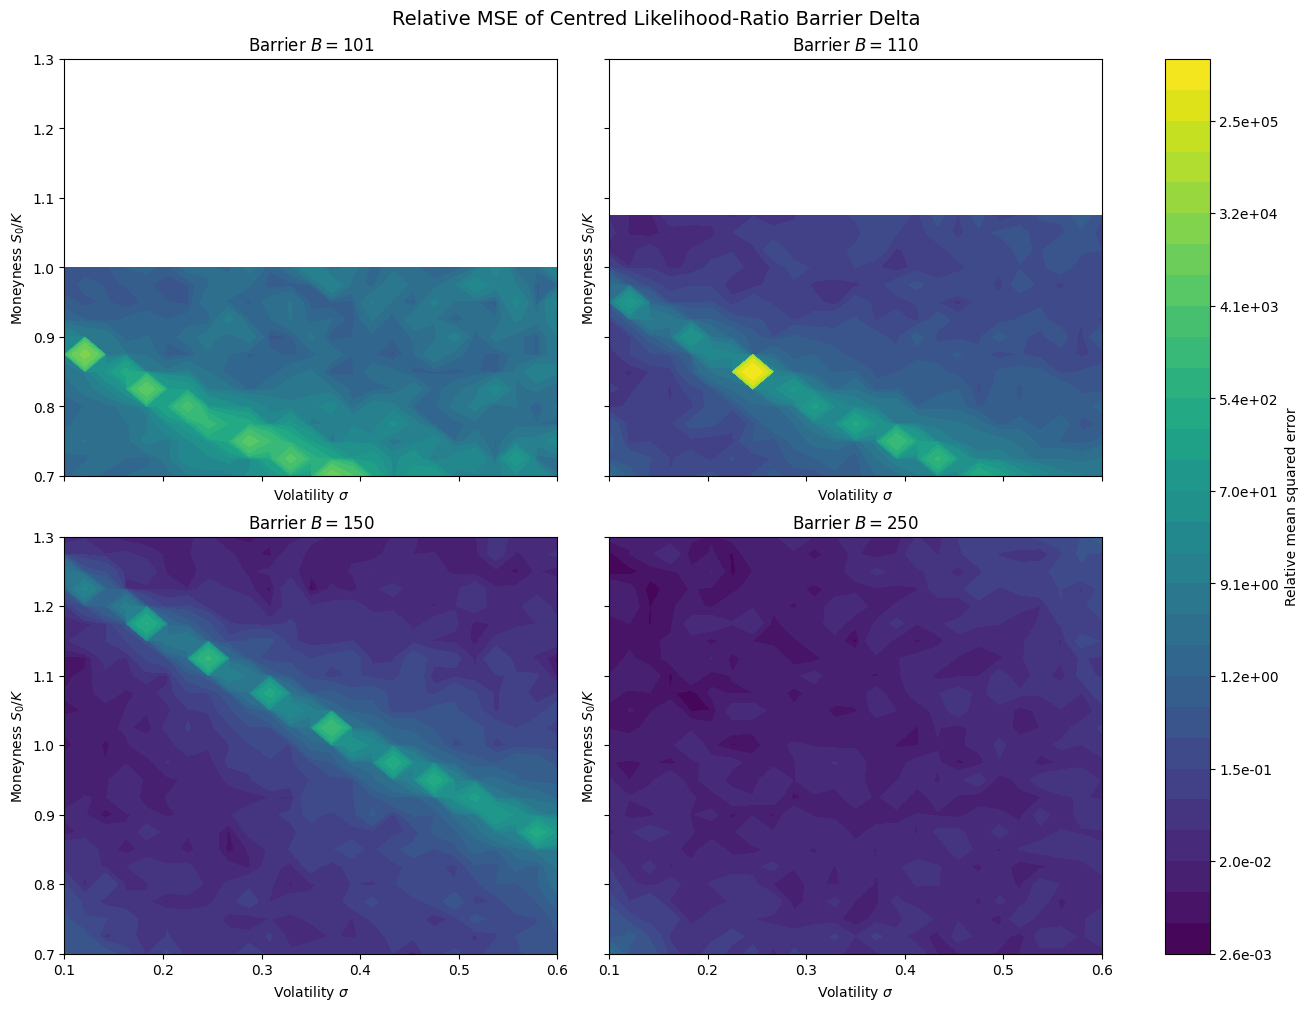

In [23]:
VOL, MONEYNESS = np.meshgrid(vol_values,moneyness_values)

all_mse = np.concatenate([mse.ravel() for mse in lr_centred_relative_mse_results.values()])
positive_finite_mse = all_mse[np.isfinite(all_mse) & (all_mse > 0)]

mse_min = positive_finite_mse.min()
mse_max = positive_finite_mse.max()

levels = np.geomspace(mse_min,mse_max,30)
normalisation = LogNorm(vmin=mse_min,vmax=mse_max)

fig,axes = plt.subplots(2,2,figsize=(13,10),sharex=True,sharey=True,constrained_layout=True)

for ax,(B,lr_centred_relative_mse) in zip(axes.ravel(),lr_centred_relative_mse_results.items()):
    plot_data = np.ma.masked_invalid(lr_centred_relative_mse)
    contour = ax.contourf(VOL,MONEYNESS,plot_data,levels=levels,norm=normalisation)
    ax.set_xlabel(r"Volatility $\sigma$")
    ax.set_ylabel(r"Moneyness $S_0/K$")
    ax.set_title(rf"Barrier $B={B}$")

cbar = fig.colorbar(contour,ax=axes.ravel().tolist(),format="%.1e")
cbar.set_label("Relative mean squared error")
fig.suptitle("Relative MSE of Centred Likelihood-Ratio Barrier Delta",fontsize=14)

plt.show()

We observe identical patterns to the MSE of LR without centring. As usual, we plot the ratio $\frac{\operatorname{MSE}(\text{LR with centring})}{\operatorname{MSE}(\text{LR without centring})}$ to check how effective the method is in reducing the LR MSE for this specific option.

In [24]:
lr_mse_ratio_results = {}

for B in barrier_values:
    lr_mse = lr_relative_mse_results[B]
    lr_centred_mse = lr_centred_relative_mse_results[B]

    lr_mse_ratio = np.empty((len(moneyness_values),len(vol_values)))

    for i,moneyness_i in enumerate(moneyness_values):
        for j,vol_j in enumerate(vol_values):
            ratio = lr_centred_mse[i,j]/lr_mse[i,j]
            lr_mse_ratio[i,j] = ratio

    lr_mse_ratio_results[B] = lr_mse_ratio

    lr_mse_ratio_error_table = pd.DataFrame(lr_mse_ratio,index=moneyness_values,columns=vol_values)
    lr_mse_ratio_error_table.index.name = "moneyness"
    lr_mse_ratio_error_table.columns.name = "vol"

    print(f"Barrier = {B}")
    display(lr_mse_ratio_error_table)

Barrier = 101


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.092743,3.215566,2.383435,2.560358,1.503056,0.529295,1.436396,1.295453,6.615928,0.812293,...,1.686632,0.285868,0.933921,5.435605,0.095163,1.525254,0.573591,1.701494,1.502897,0.193663
0.725,0.561705,0.150477,3.261854,2.858035,0.720182,0.524383,8.544714,1.847742,1.258264,0.143706,...,1.505676,0.099721,3.391384,0.256601,0.527705,4.392165,0.155695,97.951370,0.378592,0.288754
0.750,1.209599,0.768036,6.358846,0.681531,4.824481,0.901724,0.916636,0.616747,2.487060,1.354320,...,5.807132,0.120620,4.219810,1.530222,0.150157,1.534388,0.764871,4.111852,2.126476,3.517054
0.775,1.697570,1.934965,0.856104,0.397675,0.605006,3.146745,4.597371,13.162070,0.971956,1.105062,...,0.542299,12.297449,2.348892,0.161696,1.632258,1.220679,4.338740,3.281077,1.416599,0.290224
0.800,0.153397,1.041454,0.408714,1.160424,0.174824,2.306941,2.165007,0.707836,0.423201,3.688381,...,6.144908,4.367804,0.168804,0.924342,2.150569,3.428710,0.410158,0.631964,0.143176,3.282095
0.825,1.639053,1.662670,4.507738,0.496794,0.775437,0.398619,4.843522,0.904734,0.265501,0.362273,...,0.173660,1.566633,4.363223,1.395896,3.274877,6.573175,4.441278,1.320837,0.779730,1.801550
0.850,1.147177,0.639624,0.778385,0.993080,0.127279,1.633621,0.512127,1.591809,0.626348,0.406852,...,0.109373,0.687538,0.060526,1.400193,0.301602,1.846652,0.787062,1.980618,21.952967,6.753610
0.875,0.523039,0.618486,0.174566,0.698386,0.665220,0.084279,0.145171,2.255907,2.070802,0.506775,...,0.177427,0.705320,0.615305,1.032164,4.493164,0.330946,0.686690,4.504185,0.937640,6.307701
0.900,0.410803,1.980361,3.373397,0.518970,2.529117,0.564987,2.161180,5.316025,0.815375,2.742054,...,0.991492,1.044415,3.382134,0.450295,11.279939,1.058301,4.332236,0.336070,0.420210,8.196743


Barrier = 110


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,3.776261,0.250538,0.722312,0.613200,6.035513,2.787449,1.126800,1.359572,1.315465,1.412319,...,2.375086,0.881641,0.791134,0.878270,0.992928,0.643453,1.816442,0.551288,0.541158,0.921208
0.725,0.486409,1.236574,1.215109,0.909988,0.790019,0.284142,0.925703,0.315781,1.367734,0.773573,...,0.460337,1.536740,0.387765,0.642678,0.565328,0.184278,0.477172,1.817486,0.597553,1.429814
0.750,1.639917,1.120713,1.017376,0.521567,0.955170,0.582826,0.337763,2.169323,0.309791,1.319615,...,1.792364,1.272951,1.882434,1.690294,1.496532,2.097957,0.714353,1.479332,0.504899,5.214502
0.775,1.927621,1.940546,0.998714,0.410092,1.840898,1.586373,0.731523,1.040036,1.618765,2.170185,...,1.253268,0.740415,0.925685,4.721506,0.355241,0.740099,0.731122,1.712644,0.285811,0.426292
0.800,0.438230,1.045014,1.130726,0.957610,0.556440,1.990450,0.284407,1.280197,1.089117,0.648266,...,0.503022,1.474640,1.291381,0.740344,1.098545,0.771280,1.536948,0.692866,0.897927,1.899165
0.825,1.365070,2.714715,1.299650,0.593432,0.948059,0.366730,2.130015,0.693817,2.001733,0.932865,...,0.730687,0.735689,1.065498,0.326940,1.061799,0.219383,1.265009,2.629822,0.506921,0.510969
0.850,1.125095,0.385544,0.452925,0.764398,0.899154,4.058566,0.674932,1.465911,0.538927,0.558449,...,0.851070,1.656298,0.762412,0.759246,1.536459,1.459117,0.821984,3.472185,0.556869,0.882274
0.875,0.268639,0.677817,0.698274,0.919573,0.392118,0.589500,0.896144,0.203145,0.599531,1.096958,...,2.150607,0.720500,1.597475,1.048685,1.681956,0.616441,0.693616,0.926522,0.324002,0.695354
0.900,1.587074,0.797692,1.505205,1.001189,0.335965,1.625446,3.779208,0.910083,0.573622,6.129776,...,3.579201,0.417745,0.934324,1.135496,2.194200,2.050950,1.130964,1.021200,0.408844,3.688253


Barrier = 150


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.366854,0.697517,1.582324,1.008553,0.593183,10.425353,0.772676,0.619764,4.238166,3.304096,...,0.439632,0.771144,0.698709,0.973700,0.816961,0.474677,3.037741,0.772851,1.709049,0.919599
0.725,1.031561,0.488201,0.105094,1.057071,0.562786,0.709596,1.952697,1.975925,0.269796,1.104179,...,0.506195,1.129841,1.008769,1.402252,1.343370,1.732594,0.326819,1.391228,0.861175,1.502108
0.750,0.900648,0.758276,1.319577,1.374332,0.701670,0.890478,1.123006,0.616632,0.862421,1.590299,...,1.181413,2.212334,1.943460,0.394737,0.863642,2.646245,1.682582,0.940634,0.305646,4.666132
0.775,1.201324,0.878368,0.753023,0.373978,1.114937,2.851756,0.435299,0.426495,1.356914,7.171206,...,1.641141,0.606436,0.553388,1.473392,8.225902,0.222648,1.683249,0.523227,1.210679,3.247077
0.800,2.337875,0.314287,2.179716,0.732964,1.103052,1.093858,1.366437,0.345428,0.780706,3.420724,...,0.578910,2.422135,3.101996,0.843257,0.514208,0.965251,1.406570,1.271979,0.966675,3.125938
0.825,0.685304,0.867276,0.562258,1.295087,2.349744,2.210782,1.685608,0.589797,0.916376,0.206229,...,0.433463,0.749761,1.138434,0.920891,0.186555,0.741522,0.399206,2.003837,0.249278,1.685489
0.850,1.142491,3.100276,0.652388,0.390279,0.568312,0.491257,0.569176,0.869838,0.310344,1.073705,...,0.455891,1.866397,1.040756,1.404855,1.036158,0.768874,0.448482,0.738570,0.926708,0.291364
0.875,0.320892,0.531127,2.090400,0.415494,2.334746,1.016659,0.634324,0.608174,0.127450,0.541582,...,0.255125,0.597834,0.482054,0.643143,0.837044,0.864889,1.815505,1.495462,0.825960,1.202249
0.900,1.627961,0.456220,0.194926,0.942062,0.782766,0.697037,1.202766,0.721441,0.478240,0.488289,...,0.917194,0.194971,1.589340,0.662482,0.397115,0.417205,1.382883,0.791682,1.125550,1.645422


Barrier = 250


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,2.335281,1.187691,2.551469,0.821876,0.760502,2.407629,1.953438,2.245932,0.620302,1.410588,...,2.472662,0.827324,0.408316,0.911224,0.296197,0.755465,0.832230,0.584217,0.871588,0.788909
0.725,0.211353,3.361394,0.944297,0.292418,1.050463,0.672109,1.088910,0.872904,10.497680,0.737543,...,0.418184,0.376802,0.879475,0.416050,1.093546,0.225681,0.806706,0.993109,0.579976,2.029510
0.750,3.000476,0.828950,0.951790,1.558028,0.403782,1.733440,0.397784,0.575039,0.761450,0.636384,...,2.037234,0.559600,1.709145,0.684649,0.382591,1.605253,0.807360,0.615708,0.381585,2.459149
0.775,1.324340,0.672350,2.145495,0.898011,0.468078,0.561307,1.434670,1.006312,1.548858,0.271663,...,1.319991,1.412521,0.586820,1.309079,0.715026,0.435445,3.417504,0.451902,1.710474,1.965706
0.800,0.879427,1.247938,0.565009,2.551480,0.652136,1.056031,0.928945,1.737735,0.521554,0.514380,...,2.279396,2.961791,1.126410,0.441644,1.121071,0.518897,1.311809,1.165783,0.518112,0.385441
0.825,0.811787,0.651452,1.299611,0.562839,0.929997,0.774448,0.824788,0.528277,1.761913,1.007462,...,1.701441,1.408398,0.469497,0.540547,1.026135,0.228413,0.555451,0.761078,0.691966,1.104761
0.850,1.032566,0.561318,0.961152,0.788662,0.327982,0.995739,0.343209,0.730275,0.535915,0.917202,...,0.791032,0.627188,0.669048,0.546789,0.402256,0.783679,1.353286,1.732159,1.339876,1.145000
0.875,0.168290,1.252719,2.862608,1.901335,0.498848,0.254902,0.282505,1.508935,1.366279,1.157772,...,0.824810,2.249524,2.372022,1.161237,1.385683,0.606725,0.462773,1.035786,1.255405,0.629943
0.900,0.764344,1.153237,0.395553,1.079796,0.674393,0.417799,0.371572,1.104992,0.306519,2.799622,...,0.832845,1.064401,0.561474,0.496505,0.228667,0.526093,0.872573,0.804692,0.561574,0.775975


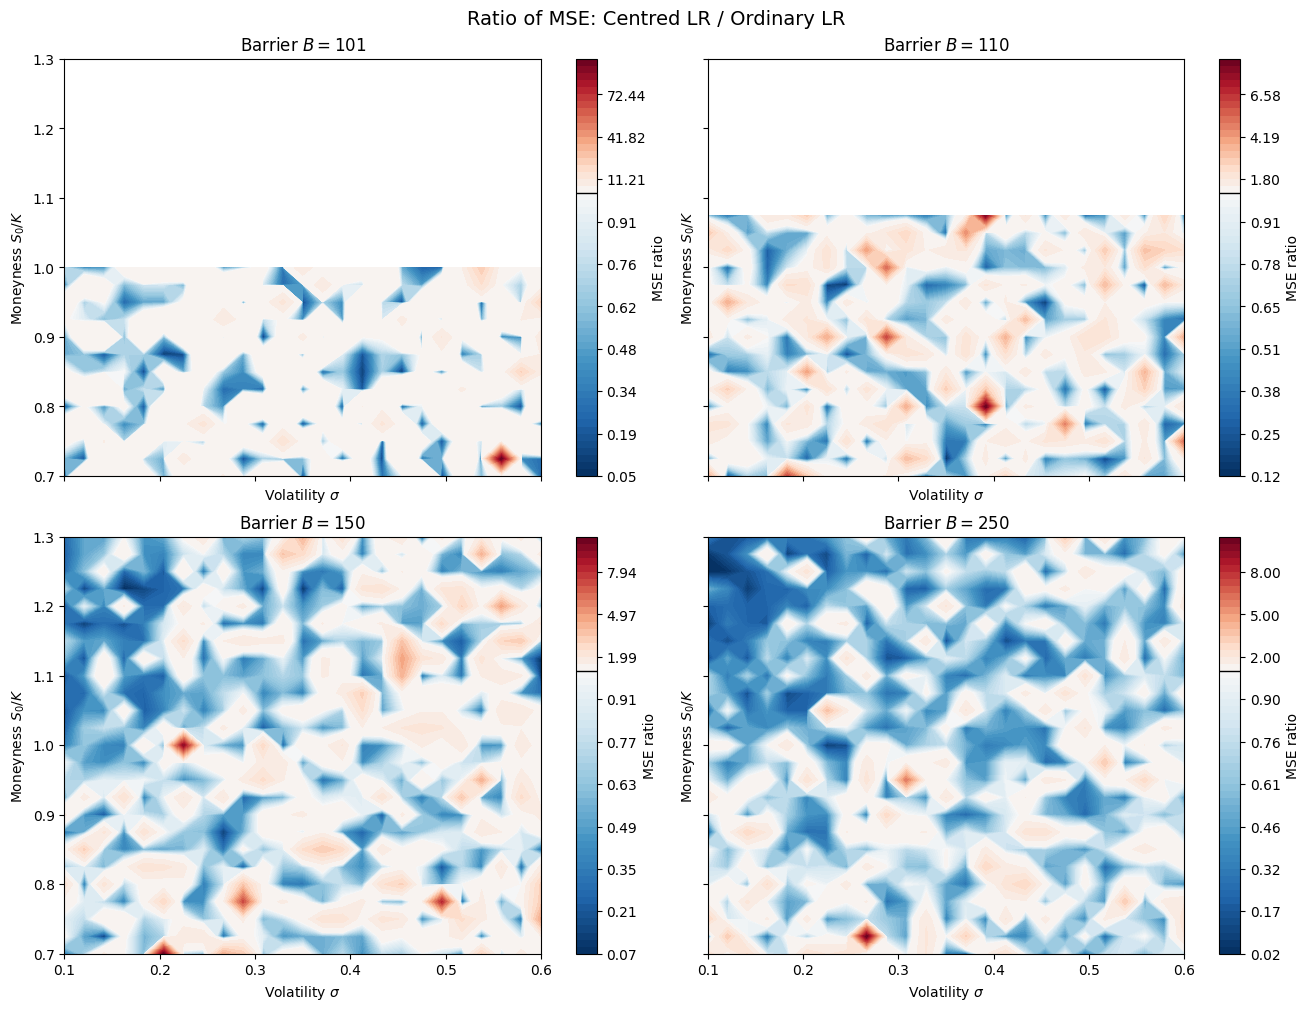

In [25]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, (B, lr_mse_ratio) in zip(axes.ravel(), lr_mse_ratio_results.items()):

    plot_data = np.ma.masked_invalid(lr_mse_ratio)
    finite_values = lr_mse_ratio[np.isfinite(lr_mse_ratio)]

    vmin = finite_values.min()
    vmax = finite_values.max()

    map_norm = TwoSlopeNorm(
        vmin=vmin,
        vcenter=1.0,
        vmax=vmax
    )

    # More resolution below 1 than above 1
    lower_levels = np.linspace(vmin, 1.0, 40, endpoint=False)
    upper_levels = np.linspace(1.0, vmax, 20)
    levels = np.concatenate([lower_levels, upper_levels])

    contour = ax.contourf(VOL,MONEYNESS,plot_data,levels=levels,cmap="RdBu_r",norm=map_norm)

    ax.set_xlabel(r"Volatility $\sigma$")
    ax.set_ylabel(r"Moneyness $S_0/K$")
    ax.set_title(rf"Barrier $B={B}$")

    cbar = fig.colorbar(contour, ax=ax, format="%.2f")
    cbar.set_label("MSE ratio")
    cbar.ax.axhline(1.0, color="black", linewidth=1)

fig.suptitle("Ratio of MSE: Centred LR / Ordinary LR", fontsize=14)

plt.show()

We observe that for low-barrier options, centring does not provide a substantial and systematic improvement of the MSE. For high-barrier options, however, it significantly improves the MSE on the high-moneyness, low-volatility region, but its effect is more moderate and less reliable on the rest of the grid.

To finish this notebook, we carry out a comparative analysis of the best versions of the three methods investigated: the Central Difference method with CRN and an optimal step size choice, the method of Pathwise Differentiation, and the Likelihood-Ratio method with Payoff Centring. We investigate the metrics MSE and MSE x Runtime, and evaluate them for each method on the usual moneyness-volatility grid at different barrier values. 

We fix $N = 1,000$ as usual, and choose the optimal step size $h$ according to the tables generated in the Finite Differences section.

In [26]:
barrier_values = [101, 110, 150, 250]

optimal_h_by_barrier = {
    101: 10.0,
    110: 10.0,
    150: 1.0,
    250: 0.5
}

trials = 10
reps = 1_000
pilot_reps = 1_000

comparison_results = {}

for B in barrier_values:
    h_B = optimal_h_by_barrier[B]
    shape = (len(moneyness_values), len(vol_values))

    # Relative MSE arrays
    cd_crn_mse = np.empty(shape)
    pw_mse = np.empty(shape)
    lr_centred_mse = np.empty(shape)

    # Runtime arrays
    cd_crn_runtime = np.empty(shape)
    pw_runtime = np.empty(shape)
    lr_centred_runtime = np.empty(shape)

    # Runtime needed to compute c
    lr_c_runtime = np.empty(shape)

    for i, moneyness_i in enumerate(moneyness_values):
        s_i = K * moneyness_i

        for j, vol_j in enumerate(vol_values):
            true_delta = theoretical_delta(s_i, K, B, T, r, vol_j)

            # Compute c once at each grid point using a separate pilot sample
            start = time.perf_counter()
            c_ij = mc_barrier_call_lr_optimal_c(s_i, K, B, T, r, vol_j, steps, pilot_reps)
            lr_c_runtime[i, j] = time.perf_counter() - start

            cd_trial_errors = np.empty(trials)
            pw_trial_errors = np.empty(trials)
            lr_trial_errors = np.empty(trials)

            cd_trial_runtimes = np.empty(trials)
            pw_trial_runtimes = np.empty(trials)
            lr_trial_runtimes = np.empty(trials)

            for trial in range(trials):
                start = time.perf_counter()
                delta_cd_crn = finite_difference.mc_barrier_call_delta_cd_estimate_crn(s_i, K, B, T, r, vol_j, steps, reps, h_B)
                cd_trial_runtimes[trial] = time.perf_counter() - start

                start = time.perf_counter()
                delta_pw = pathwise.mc_barrier_call_delta_pw_estimate(s_i, K, B, T, r, vol_j, steps, reps)
                pw_trial_runtimes[trial] = time.perf_counter() - start

                start = time.perf_counter()
                delta_lr_centred = likelihood_ratio.mc_barrier_call_delta_lr_centred_estimate(s_i, K, B, T, r, vol_j, steps, reps, c_ij)
                lr_trial_runtimes[trial] = time.perf_counter() - start

                cd_trial_errors[trial] = ((delta_cd_crn - true_delta) / true_delta)**2
                pw_trial_errors[trial] = ((delta_pw - true_delta) / true_delta)**2
                lr_trial_errors[trial] = ((delta_lr_centred - true_delta) / true_delta)**2

            cd_crn_mse[i, j] = np.mean(cd_trial_errors)
            pw_mse[i, j] = np.mean(pw_trial_errors)
            lr_centred_mse[i, j] = np.mean(lr_trial_errors)

            cd_crn_runtime[i, j] = np.mean(cd_trial_runtimes)
            pw_runtime[i, j] = np.mean(pw_trial_runtimes)
            lr_centred_runtime[i, j] = np.mean(lr_trial_runtimes)

    comparison_results[B] = {
        "h": h_B,
        "cd_crn_mse": cd_crn_mse,
        "pw_mse": pw_mse,
        "lr_centred_mse": lr_centred_mse,
        "cd_crn_runtime": cd_crn_runtime,
        "pw_runtime": pw_runtime,
        "lr_centred_runtime": lr_centred_runtime,
        "lr_c_runtime": lr_c_runtime
    }

/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/3702016145.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  cd_trial_errors[trial] = ((delta_cd_crn - true_delta) / true_delta)**2
/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/3702016145.py:66: RuntimeWarning: invalid value encountered in scalar divide
  pw_trial_errors[trial] = ((delta_pw - true_delta) / true_delta)**2
/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/3702016145.py:67: RuntimeWarning: invalid value encountered in scalar divide
  lr_trial_errors[trial] = ((delta_lr_centred - true_delta) / true_delta)**2
/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/3702016145.py:65: RuntimeWarning: invalid value encountered in scalar divide
  cd_trial_errors[trial] = ((delta_cd_crn - true_delta) / true_delta)**2


In [27]:
for B in barrier_values:
    result = comparison_results[B]

    runtime_rows = []

    for i, moneyness_i in enumerate(moneyness_values):
        for j, vol_j in enumerate(vol_values):
            runtime_rows.append({
                "moneyness": moneyness_i,
                "volatility": vol_j,
                "CD with CRN": 1_000 * result["cd_crn_runtime"][i, j],
                "Pathwise": 1_000 * result["pw_runtime"][i, j],
                "Centred LR estimator": 1_000 * result["lr_centred_runtime"][i, j],
                "Computation of c": 1_000 * result["lr_c_runtime"][i, j],
                "Total centred LR": 1_000 * (result["lr_centred_runtime"][i, j] + result["lr_c_runtime"][i, j])
            })

    runtime_comparison_table = pd.DataFrame(runtime_rows).set_index(["moneyness", "volatility"])
    runtime_comparison_table.columns.name = "Runtime in milliseconds"

    print(f"Barrier = {B}, h = {result['h']}")
    display(runtime_comparison_table)

Barrier = 101, h = 10.0


Runtime in milliseconds  CD with CRN  Pathwise  Centred LR estimator  \
moneyness volatility                                                   
0.7       0.100000          0.947237  1.262900              0.567362   
          0.120833          0.946421  1.016479              0.850154   
          0.141667          0.696771  0.560838              0.474816   
          0.162500          0.685262  0.553296              0.463292   
          0.183333          0.685354  0.547542              0.460813   
...                              ...       ...                   ...   
1.3       0.516667          0.673471  0.278146              0.276662   
          0.537500          0.671729  0.275384              0.279550   
          0.558333          0.672633  0.274279              0.276996   
          0.579167          0.673396  0.277404              0.276617   
          0.600000          0.677396  0.273442              0.275845   

Runtime in milliseconds  Computation of c  Total centred LR  
moneyness volatility                                         
0.7       0.100000               1.113917          1.681279  
          0.120833               0.521209          1.371363  
          0.141667               0.509917          0.984733  
          0.162500               0.478416          0.941708  
          0.183333               0.467375          0.928188  
...                                   ...               ...  
1.3       0.516667               0.311167          0.587830  
          0.537500               0.276584          0.556134  
          0.558333               0.277958          0.554954  
          0.579167               0.275042          0.551659  
          0.600000               0.290041          0.565887  

[625 rows x 5 columns]

Barrier = 110, h = 10.0


Runtime in milliseconds  CD with CRN  Pathwise  Centred LR estimator  \
moneyness volatility                                                   
0.7       0.100000          0.689138  0.555092              0.464708   
          0.120833          0.676750  0.558954              0.464958   
          0.141667          0.681650  0.558871              0.465625   
          0.162500          0.686941  0.557858              0.464321   
          0.183333          0.687858  0.556867              0.465704   
...                              ...       ...                   ...   
1.3       0.516667          0.674321  0.273904              0.276246   
          0.537500          0.678058  0.274533              0.278846   
          0.558333          0.677271  0.276171              0.279771   
          0.579167          0.680125  0.273883              0.281492   
          0.600000          0.679017  0.274950              0.275525   

Runtime in milliseconds  Computation of c  Total centred LR  
moneyness volatility                                         
0.7       0.100000               0.477875          0.942583  
          0.120833               0.474208          0.939166  
          0.141667               0.476375          0.942000  
          0.162500               0.477333          0.941654  
          0.183333               0.464125          0.929829  
...                                   ...               ...  
1.3       0.516667               0.278750          0.554996  
          0.537500               0.275000          0.553846  
          0.558333               0.278792          0.558563  
          0.579167               0.275083          0.556575  
          0.600000               0.274250          0.549775  

[625 rows x 5 columns]

Barrier = 150, h = 1.0


Runtime in milliseconds  CD with CRN  Pathwise  Centred LR estimator  \
moneyness volatility                                                   
0.7       0.100000          0.651258  0.514850              0.434450   
          0.120833          0.690983  0.530479              0.457262   
          0.141667          0.675038  0.522446              0.445558   
          0.162500          0.673050  0.519396              0.443108   
          0.183333          0.668717  0.519817              0.444017   
...                              ...       ...                   ...   
1.3       0.516667          0.699283  0.414450              0.381075   
          0.537500          0.697996  0.416567              0.375058   
          0.558333          0.706867  0.424408              0.382912   
          0.579167          0.701129  0.416579              0.378896   
          0.600000          0.704479  0.411833              0.378654   

Runtime in milliseconds  Computation of c  Total centred LR  
moneyness volatility                                         
0.7       0.100000               0.446083          0.880533  
          0.120833               0.458917          0.916179  
          0.141667               0.465416          0.910974  
          0.162500               0.455000          0.898108  
          0.183333               0.466375          0.910392  
...                                   ...               ...  
1.3       0.516667               0.388125          0.769200  
          0.537500               0.380625          0.755683  
          0.558333               0.383833          0.766745  
          0.579167               0.389792          0.768688  
          0.600000               0.379166          0.757820  

[625 rows x 5 columns]

Barrier = 250, h = 0.5


Runtime in milliseconds  CD with CRN  Pathwise  Centred LR estimator  \
moneyness volatility                                                   
0.7       0.100000          0.643309  0.508612              0.437238   
          0.120833          0.647363  0.506254              0.441329   
          0.141667          0.649738  0.510617              0.431854   
          0.162500          0.648729  0.510509              0.440091   
          0.183333          0.674946  0.517725              0.438321   
...                              ...       ...                   ...   
1.3       0.516667          0.697950  0.519033              0.441742   
          0.537500          0.697854  0.517725              0.440796   
          0.558333          0.696008  0.512425              0.440050   
          0.579167          0.699863  0.510929              0.445308   
          0.600000          0.701158  0.511333              0.433496   

Runtime in milliseconds  Computation of c  Total centred LR  
moneyness volatility                                         
0.7       0.100000               0.438375          0.875613  
          0.120833               0.434625          0.875954  
          0.141667               0.437500          0.869354  
          0.162500               0.437792          0.877883  
          0.183333               0.442042          0.880363  
...                                   ...               ...  
1.3       0.516667               0.445584          0.887326  
          0.537500               0.441625          0.882421  
          0.558333               0.437167          0.877217  
          0.579167               0.440208          0.885516  
          0.600000               0.438584          0.872080  

[625 rows x 5 columns]

In [28]:
for B in barrier_values:
    result = comparison_results[B]

    cd_crn_runtime_mse = result["cd_crn_mse"] * result["cd_crn_runtime"]
    pw_runtime_mse = result["pw_mse"] * result["pw_runtime"]
    lr_total_runtime = result["lr_centred_runtime"] + result["lr_c_runtime"]
    lr_centred_runtime_mse = result["lr_centred_mse"] * lr_total_runtime

    runtime_mse_rows = []

    for i, moneyness_i in enumerate(moneyness_values):
        for j, vol_j in enumerate(vol_values):
            runtime_mse_rows.append({
                "moneyness": moneyness_i,
                "volatility": vol_j,
                "CD with CRN": cd_crn_runtime_mse[i, j],
                "Pathwise": pw_runtime_mse[i, j],
                "Centred LR": lr_centred_runtime_mse[i, j]
            })

    runtime_mse_table = pd.DataFrame(runtime_mse_rows).set_index(["moneyness", "volatility"])
    runtime_mse_table["Best method"] = runtime_mse_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)

    print(f"Barrier = {B}, h = {result['h']}")
    display(runtime_mse_table)

Barrier = 101, h = 10.0


/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/2579211417.py:22: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  runtime_mse_table["Best method"] = runtime_mse_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)


CD with CRN  Pathwise  Centred LR  Best method
moneyness volatility                                                
0.7       0.100000       0.002058  0.761631    0.002093  CD with CRN
          0.120833       0.000234  0.524153    0.008292  CD with CRN
          0.141667       0.000073  0.319196    0.003333  CD with CRN
          0.162500       0.000107  0.172859    0.000874  CD with CRN
          0.183333       0.000141  0.855982    0.001492  CD with CRN
...                           ...       ...         ...          ...
1.3       0.516667            NaN       NaN         NaN          NaN
          0.537500            NaN       NaN         NaN          NaN
          0.558333            NaN       NaN         NaN          NaN
          0.579167            NaN       NaN         NaN          NaN
          0.600000            NaN       NaN         NaN          NaN

[625 rows x 4 columns]

Barrier = 110, h = 10.0


/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_11251/2579211417.py:22: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  runtime_mse_table["Best method"] = runtime_mse_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)


CD with CRN  Pathwise  Centred LR  Best method
moneyness volatility                                                
0.7       0.100000       0.007866  0.003969    0.000822   Centred LR
          0.120833       0.000496  0.000346    0.000545     Pathwise
          0.141667       0.000050  0.000343    0.000193  CD with CRN
          0.162500       0.000012  0.000330    0.000331  CD with CRN
          0.183333       0.000012  0.000451    0.000170  CD with CRN
...                           ...       ...         ...          ...
1.3       0.516667            NaN       NaN         NaN          NaN
          0.537500            NaN       NaN         NaN          NaN
          0.558333            NaN       NaN         NaN          NaN
          0.579167            NaN       NaN         NaN          NaN
          0.600000            NaN       NaN         NaN          NaN

[625 rows x 4 columns]

Barrier = 150, h = 1.0


CD with CRN  Pathwise  Centred LR  Best method
moneyness volatility                                                
0.7       0.100000       0.000640  0.000767    0.003436  CD with CRN
          0.120833       0.000154  0.000066    0.001246     Pathwise
          0.141667       0.000056  0.000037    0.000350     Pathwise
          0.162500       0.000030  0.000010    0.000099     Pathwise
          0.183333       0.000007  0.000014    0.000125  CD with CRN
...                           ...       ...         ...          ...
1.3       0.516667       0.000061  0.000018    0.000014   Centred LR
          0.537500       0.000032  0.000018    0.000008   Centred LR
          0.558333       0.000094  0.000039    0.000006   Centred LR
          0.579167       0.000095  0.000013    0.000030     Pathwise
          0.600000       0.000043  0.000030    0.000039     Pathwise

[625 rows x 4 columns]

Barrier = 250, h = 0.5


CD with CRN  Pathwise  Centred LR  Best method
moneyness volatility                                                
0.7       0.100000       0.000836  0.000625    0.000844     Pathwise
          0.120833       0.000121  0.000126    0.001101  CD with CRN
          0.141667       0.000074  0.000051    0.000316     Pathwise
          0.162500       0.000018  0.000027    0.000202  CD with CRN
          0.183333       0.000015  0.000011    0.000165     Pathwise
...                           ...       ...         ...          ...
1.3       0.516667       0.000374  0.000274    0.000153   Centred LR
          0.537500       0.000175  0.000143    0.000112   Centred LR
          0.558333       0.000231  0.000119    0.000269     Pathwise
          0.579167       0.000749  0.000282    0.000518     Pathwise
          0.600000       0.001617  0.001054    0.000734   Centred LR

[625 rows x 4 columns]

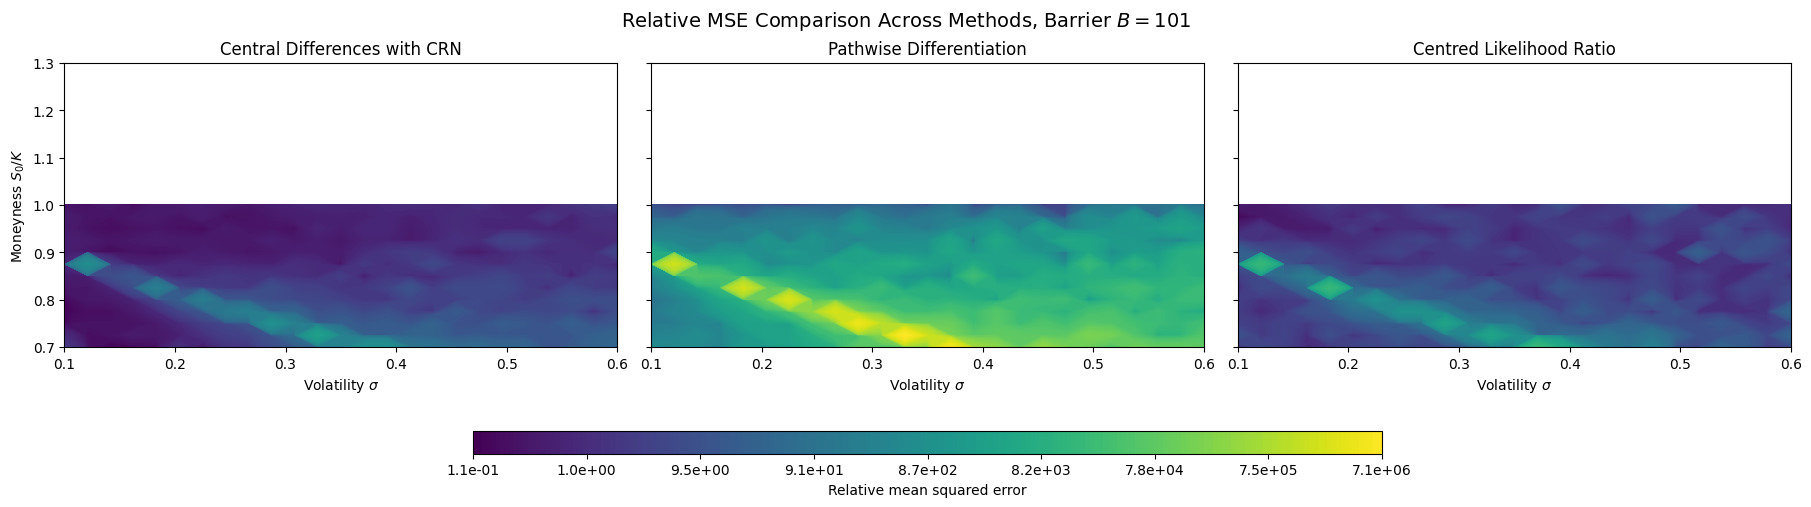

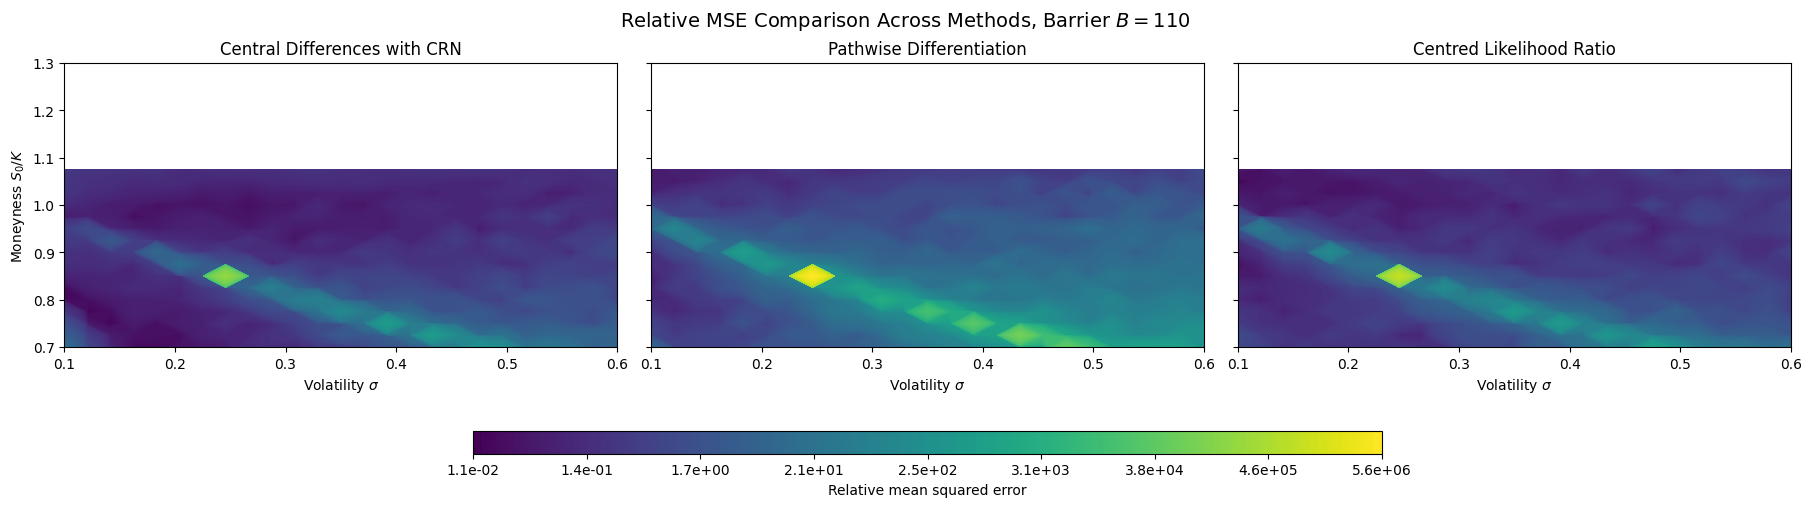

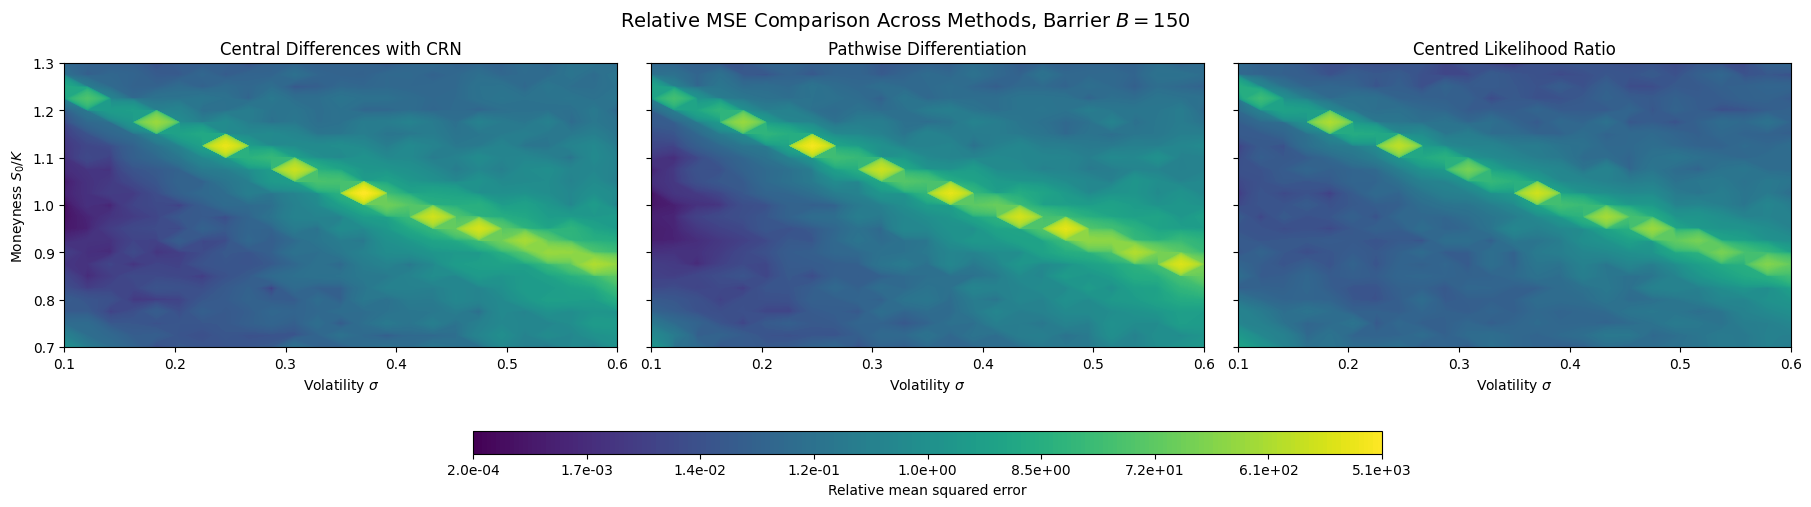

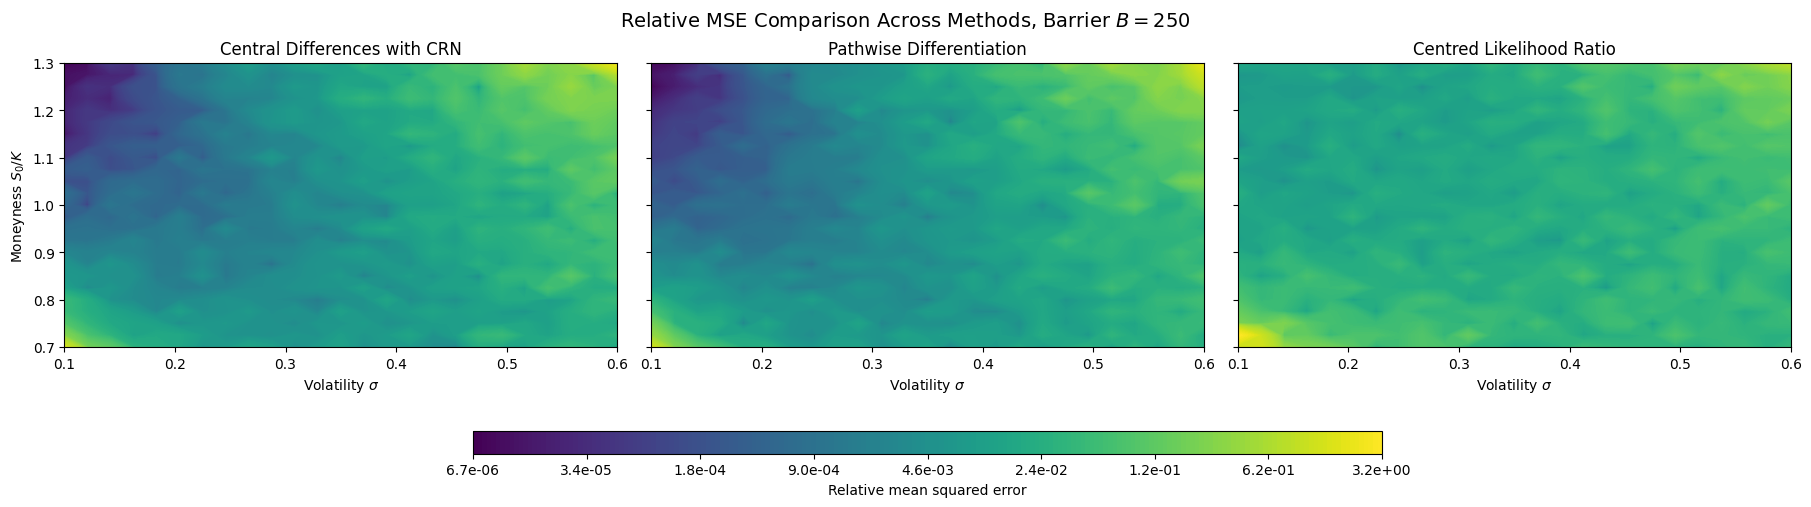

In [29]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

titles = ["Central Differences with CRN", "Pathwise Differentiation", "Centred Likelihood Ratio"]

for B in barrier_values:
    result = comparison_results[B]

    mse_data = [
        result["cd_crn_mse"],
        result["pw_mse"],
        result["lr_centred_mse"]
    ]

    all_mse = np.concatenate([data.ravel() for data in mse_data])
    positive_finite_mse = all_mse[np.isfinite(all_mse) & (all_mse > 0)]

    mse_vmin = positive_finite_mse.min()
    mse_vmax = positive_finite_mse.max()
    mse_levels = np.geomspace(mse_vmin, mse_vmax, 200)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

    for ax, data, title in zip(axes, mse_data, titles):
        plot_data = np.ma.masked_invalid(data)

        contour = ax.contourf(
            VOL,
            MONEYNESS,
            plot_data,
            levels=mse_levels,
            norm=LogNorm(vmin=mse_vmin, vmax=mse_vmax),
            cmap="viridis"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Volatility $\sigma$")

    axes[0].set_ylabel(r"Moneyness $S_0/K$")

    mse_ticks = np.geomspace(mse_vmin, mse_vmax, 9)
    cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=mse_ticks)
    cbar.set_label("Relative mean squared error")
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1e"))

    fig.suptitle(rf"Relative MSE Comparison Across Methods, Barrier $B={B}$", fontsize=14)

    plt.show()

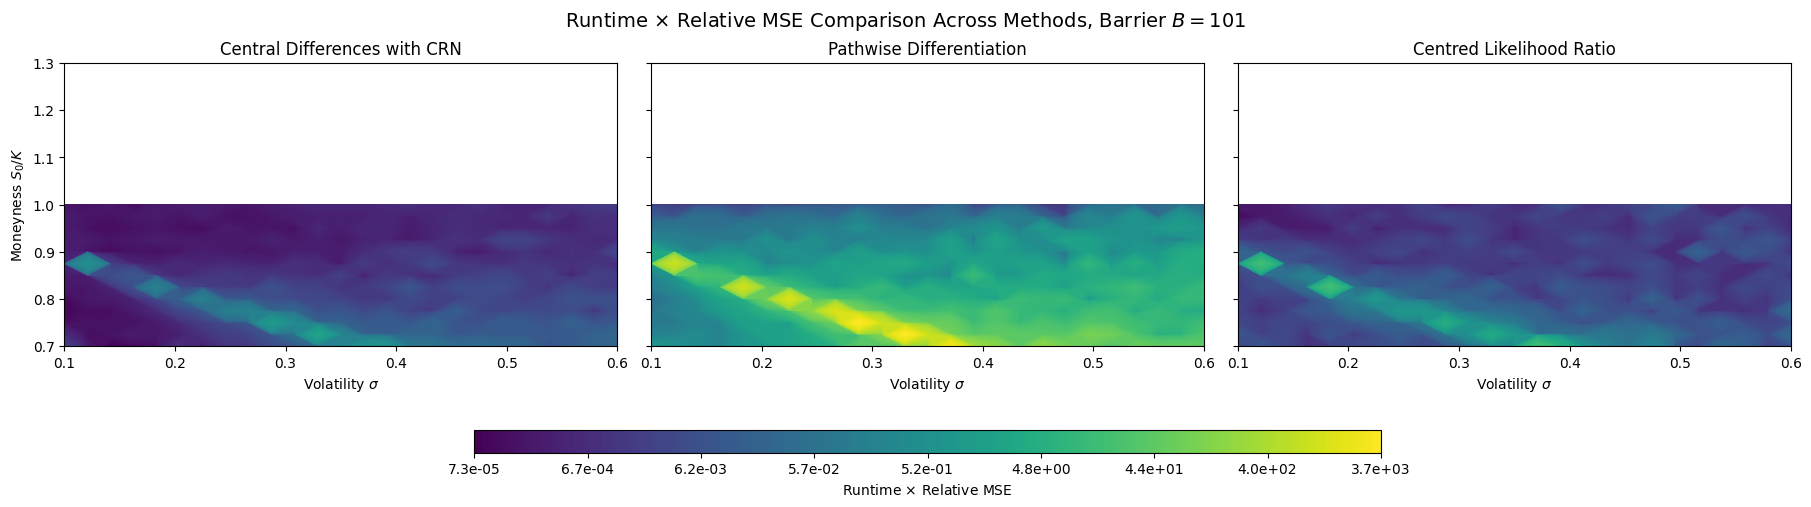

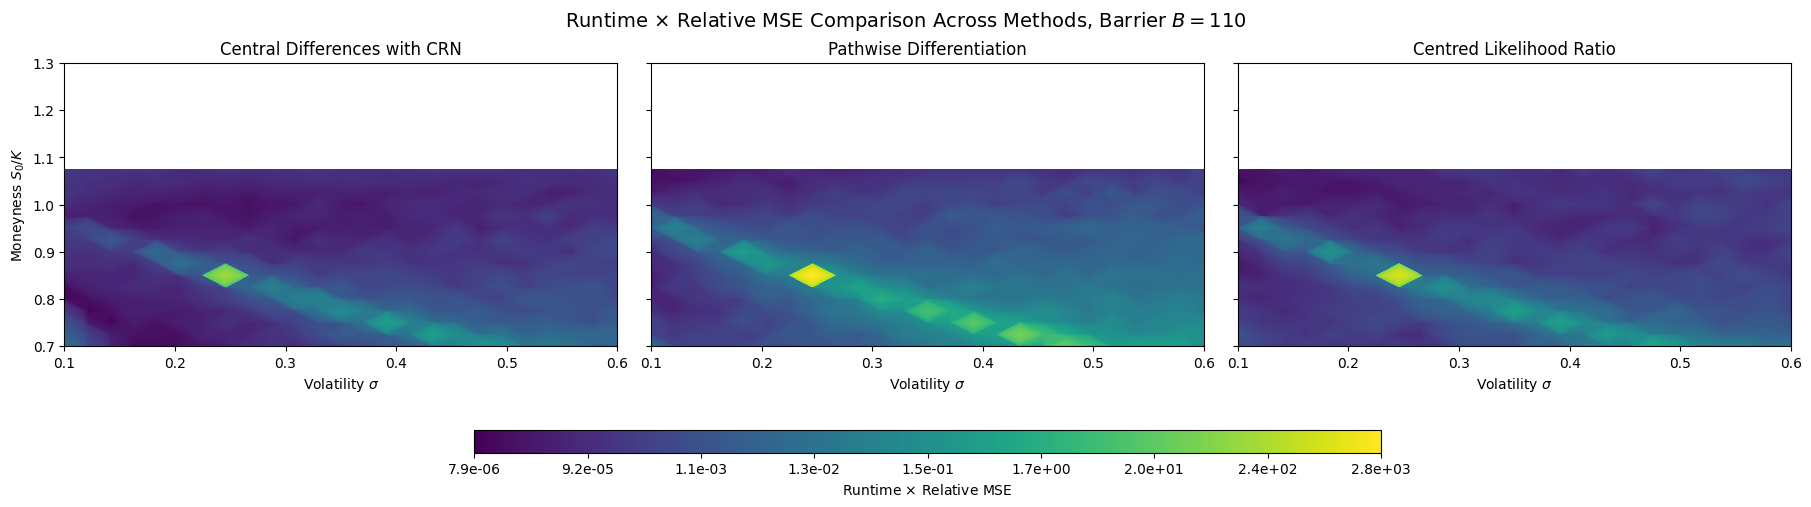

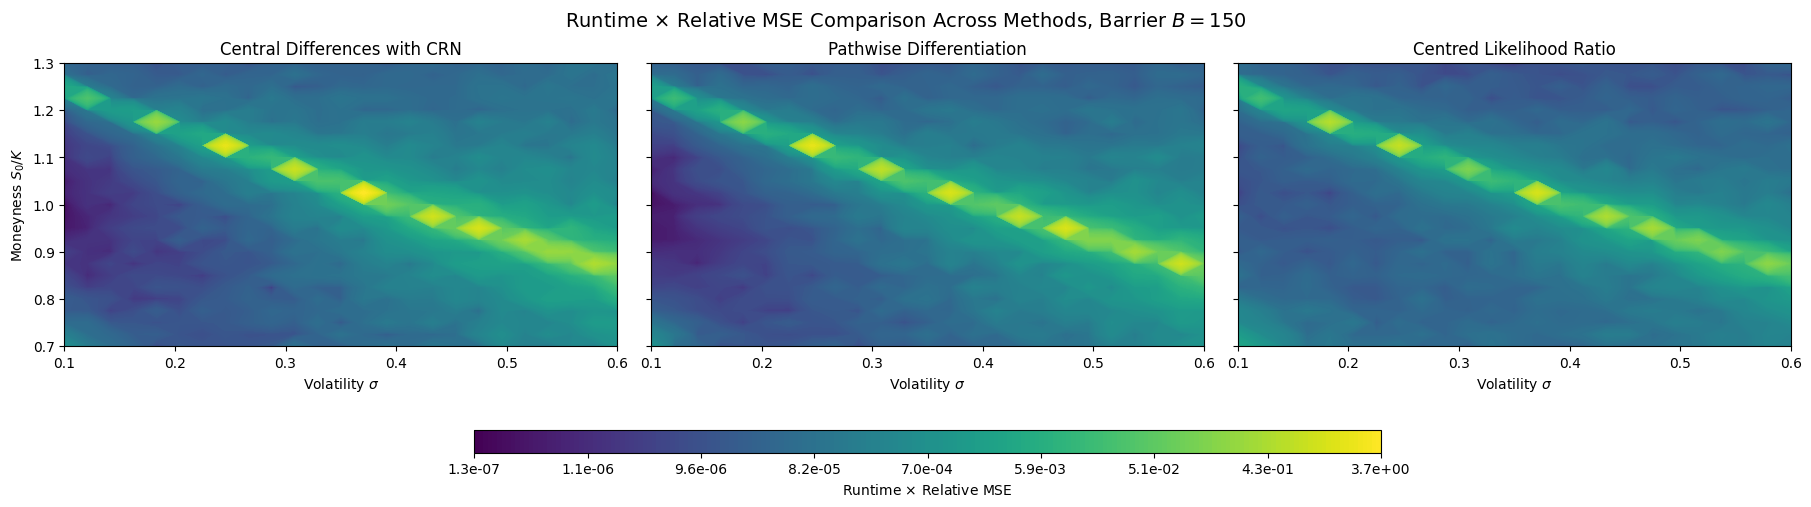

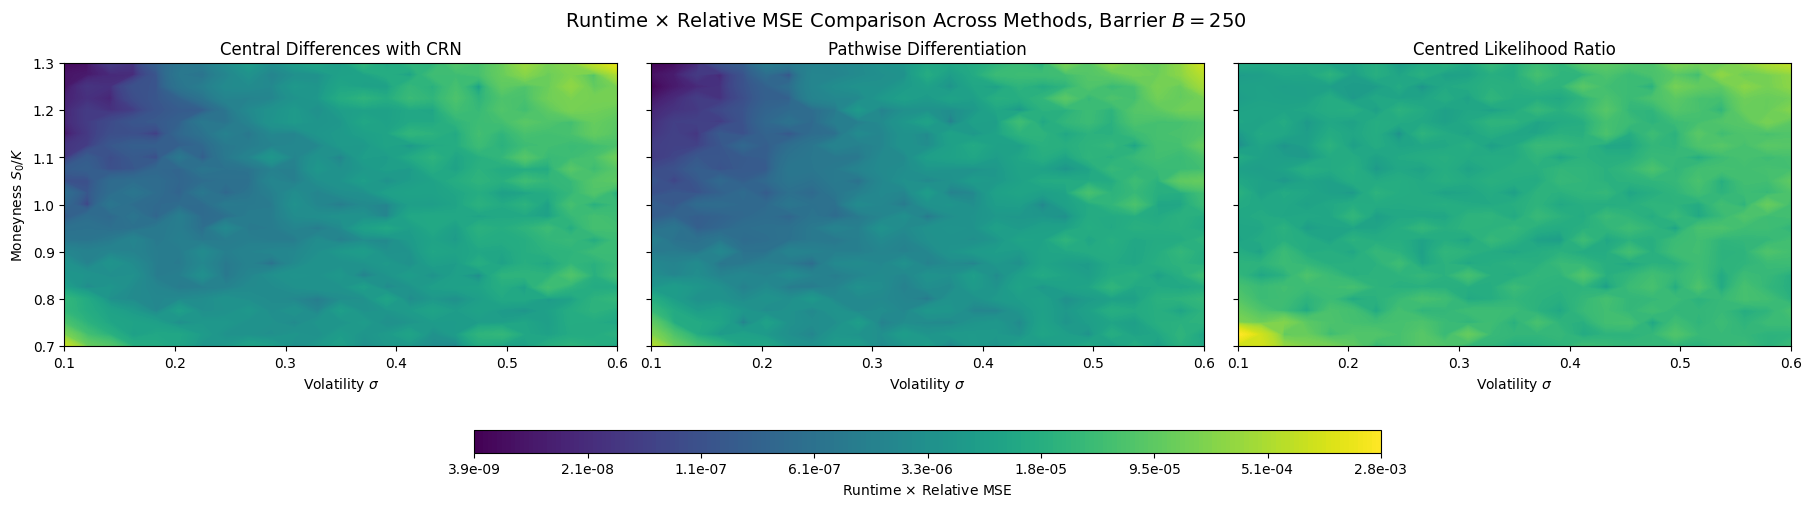

In [30]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

titles = [
    "Central Differences with CRN",
    "Pathwise Differentiation",
    "Centred Likelihood Ratio"
]

for B in barrier_values:
    result = comparison_results[B]

    # Runtime x Relative MSE
    cd_crn_runtime_mse = result["cd_crn_mse"] * result["cd_crn_runtime"]

    pw_runtime_mse = result["pw_mse"] * result["pw_runtime"]

    lr_total_runtime = (
        result["lr_centred_runtime"]
        + result["lr_c_runtime"]
    )

    lr_centred_runtime_mse = (
        result["lr_centred_mse"]
        * lr_total_runtime
    )

    runtime_mse_data = [
        cd_crn_runtime_mse,
        pw_runtime_mse,
        lr_centred_runtime_mse
    ]

    # Common colour scale within each barrier
    all_runtime_mse = np.concatenate([
        data.ravel() for data in runtime_mse_data
    ])

    positive_finite_runtime_mse = all_runtime_mse[
        np.isfinite(all_runtime_mse) & (all_runtime_mse > 0)
    ]

    runtime_mse_vmin = positive_finite_runtime_mse.min()
    runtime_mse_vmax = positive_finite_runtime_mse.max()

    runtime_mse_levels = np.geomspace(
        runtime_mse_vmin,
        runtime_mse_vmax,
        200
    )

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    for ax, data, title in zip(axes, runtime_mse_data, titles):
        plot_data = np.ma.masked_invalid(data)

        contour = ax.contourf(VOL,MONEYNESS,plot_data,levels=runtime_mse_levels,
                norm=LogNorm(
                vmin=runtime_mse_vmin,
                vmax=runtime_mse_vmax
            ),
            cmap="viridis"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Volatility $\sigma$")

    axes[0].set_ylabel(r"Moneyness $S_0/K$")

    runtime_mse_ticks = np.geomspace(
        runtime_mse_vmin,
        runtime_mse_vmax,
        9
    )

    cbar = fig.colorbar(
        contour,
        ax=axes,
        orientation="horizontal",
        pad=0.12,
        fraction=0.08,
        aspect=40,
        ticks=runtime_mse_ticks
    )

    cbar.set_label(r"Runtime $\times$ Relative MSE")
    cbar.ax.xaxis.set_major_formatter(
        FormatStrFormatter("%.1e")
    )

    fig.suptitle(
        rf"Runtime $\times$ Relative MSE Comparison Across Methods, Barrier $B={B}$",
        fontsize=14
    )

    plt.show()

The results obtained above highlight a clear result: for low-barrier options, the Central Difference method with CRN under an empirically optimal choice of $h$ behaves the best over most of the grid and under both metrics, with the Likelihood-Ratio method showing similar but generally worse results. For high-barrier options, the adapted Pathwise Differentiation method provides the best estimations. This agrees with the previous notebooks, since European-like behaviour was found to be best handled by the Pathwise Differentiation method. However, the apparent Central Difference dominance for nearby barriers should be interpreted carefully, as some empirically optimal values of $h$ produce relatively non-local approximations whose intervals reach or cross the knockout boundary. If $h$ is restricted to sufficiently local values, payoff discontinuities may be better handled by the Likelihood-Ratio method. Nonetheless, the Central Difference method with CRN behaves well in a consistent manner: so long as the optimal step size $h$ is varied according to the barrier size and the number of simulations conducted, it is reliable across different barrier values and its MSE results are not far from being the best relative to the other methods.

Consequently, when the size of the barrier or its effect on the option is unknown, the most reliable estimator may be the one produced by the Central Difference method with CRN. However, for concrete high-barrier options, the Pathwise method is better suited. For low-barrier options, the Central Difference method may produce the lowest empirical MSE when non-local step sizes are permitted, while the Likelihood-Ratio method is generally preferable when $h$ is restricted to represent a sufficiently local approximation.